In [1]:
# !pip install librosa tslearn stumpy matplotlib
import os
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesResampler
from tslearn.clustering import TimeSeriesKMeans
from tslearn.shapelets import LearningShapelets
import stumpy # Per Motif e Anomalies

/home/filippo/prova/venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
ERROR:numba.cuda.cudadrv.driver:Call to cuInit results in CUDA_ERROR_NO_DEVICE


In [2]:
data = 'dataset/df_fedez_fibra.csv'
index_col = 0
df = pd.read_csv(data, sep=',', index_col=index_col)

pd.set_option('display.max_columns', None)

In [3]:
# Trasforma l'indice in colonna e rinominala
df = df.reset_index().rename(columns={'index': 'track_id'})

In [4]:
AUDIO_COLS = [
    # Audio/Acoustic Features (Using a representative sample)
    'bpm', 'centroid', 'flux', 'rms', 'spectral_complexity', 'pitch', 'flatness', 'duration_ms'
]

## Analyzing similarity from mp3 files

In [5]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.effects
from tslearn.utils import to_time_series_dataset
from tqdm.notebook import tqdm

# Define the base directory where your files are stored
base_dir = os.path.join('dataset', 'fedez_fibra')

# Construct the file path using string formatting
# The format is: directory/id_artist - track_id.mp3
df['file_path'] = df.apply(
    lambda row: os.path.join(base_dir, f"{row['id_artist']} - {row['track_id']}.mp3"), 
    axis=1
)

# Optional: Verify if the files actually exist
# This creates a boolean column 'file_exists'
df['file_exists'] = df['file_path'].apply(os.path.exists)

# Check the first few rows
print(df[['id_artist', 'track_id', 'file_path', 'file_exists']].head())

     id_artist  track_id                                       file_path  \
0  ART25707984  TR434327  dataset\fedez_fibra\ART25707984 - TR434327.mp3   
1  ART25707984  TR443742  dataset\fedez_fibra\ART25707984 - TR443742.mp3   
2  ART25707984  TR252912  dataset\fedez_fibra\ART25707984 - TR252912.mp3   
3  ART25707984  TR316896  dataset\fedez_fibra\ART25707984 - TR316896.mp3   
4  ART25707984  TR466521  dataset\fedez_fibra\ART25707984 - TR466521.mp3   

   file_exists  
0         True  
1         True  
2         True  
3         True  
4         True  


## Use librosa to extract song lenght from audio

In [7]:
# Filter only existing files to avoid errors
df_valid = df[df['file_exists'] == True].copy()

print(f"Checking duration of {len(df_valid)} tracks...")

durations = []
# Loop through paths (tqdm shows a progress bar)
for path in tqdm(df_valid['file_path']):
    try:
        # librosa.get_duration is much faster than librosa.load
        # it reads metadata instead of decoding the whole audio
        d = librosa.get_duration(path=path)
        durations.append(d)
    except Exception as e:
        print(f"Error reading {path}: {e}")
        durations.append(None)

df_valid['duration_sec'] = durations

# Drop any failed reads
df_valid = df_valid.dropna(subset=['duration_sec'])

print("\n--- ✅ Duration Check Complete ---")
print(df_valid[['id_artist', 'duration_sec']].head())

Checking duration of 454 tracks...


  0%|          | 0/454 [00:00<?, ?it/s]


--- ✅ Duration Check Complete ---
     id_artist  duration_sec
0  ART25707984    265.729167
1  ART25707984    259.666667
2  ART25707984    219.986667
3  ART25707984    304.320979
4  ART25707984    215.146667


Mean:   214.26 s
Median: 205.82 s
Min:    28.52 s
Max:    672.01 s


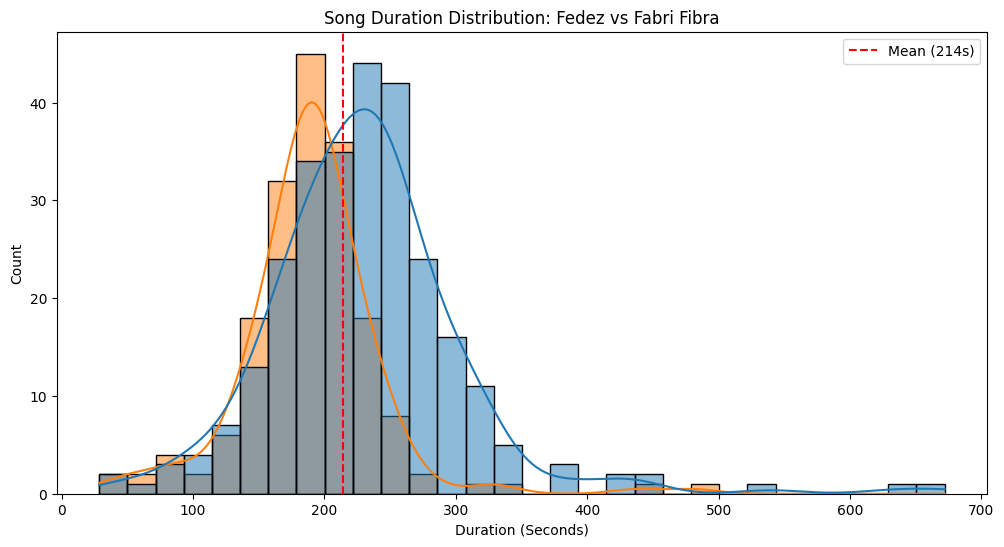

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
mean_dur = df_valid['duration_sec'].mean()
median_dur = df_valid['duration_sec'].median()
min_dur = df_valid['duration_sec'].min()
max_dur = df_valid['duration_sec'].max()

print(f"Mean:   {mean_dur:.2f} s")
print(f"Median: {median_dur:.2f} s")
print(f"Min:    {min_dur:.2f} s")
print(f"Max:    {max_dur:.2f} s")

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(data=df_valid, x='duration_sec', hue='id_artist', kde=True, bins=30, alpha=0.5)
plt.axvline(mean_dur, color='red', linestyle='--', label=f'Mean ({mean_dur:.0f}s)')
plt.title('Song Duration Distribution: Fedez vs Fabri Fibra')
plt.xlabel('Duration (Seconds)')
plt.legend()
plt.show()

## Check on outliers and remove duplicates

In [9]:
print(df_valid[df_valid['duration_sec'] < 60] [['track_id', 'duration_sec', 'title']])

print(df_valid[df_valid['duration_sec'] > 8*60] [['track_id', 'duration_sec', 'title']])

# Possibly dropp the 2 intro since they are not songs.
# Possibly drop long songs due to fixed resampling

# 1. Create a list of the specific IDs you want to remove
# Replace these strings with the actual IDs from your print output
ids_to_remove = ['TR408042', 'TR246352'
,  'TR512155'
,  'TR267048'
,   'TR300576'
,  'TR420459']

# 2. Filter the dataframe
# The '~' symbol means "NOT", so we keep everything that is NOT in the list
df_valid = df_valid[~df_valid['track_id'].isin(ids_to_remove)].copy()

# 3. Verify they are gone
print(f"Removed {len(ids_to_remove)} tracks.")
print(f"Remaining songs: {len(df_valid)}")

     track_id  duration_sec                                      title
230  TR408042     34.613333                               2031 (Intro)
246  TR868123     49.826667                              Grandi Viaggi
261  TR739987     53.638104                   Freestyle a Radio Deejay
328  TR403785     47.902771                            TONY LUCRARELLI
372  TR939101     28.522667  The Ferragnez: La serie - Sigla ufficiale
391  TR246352     56.120000                       Pop-hoolismo (Intro)
402  TR680926     53.336250                                      SUSHI
     track_id  duration_sec                title
10   TR589489    672.008708  Niente Di Personale
21   TR239743    633.765458       Fatti Da Parte
139  TR983233    539.980063    Idee Stupide 2016
421  TR414330    480.339604             BANCOMAT
Removed 6 tracks.
Remaining songs: 448


In [10]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from tslearn.preprocessing import TimeSeriesResampler, TimeSeriesScalerMeanVariance

def load_audio(path: str, sr: int = 22050, mono: bool = True, top_db: int = 25):
    """Carica l'audio, esegue il resample, converte in mono e rimuove i silenzi."""
    try:
        # Caricamento
        y, sr_out = librosa.load(path, sr=sr, mono=mono)
        
        if y is None or y.size == 0:
            return None, sr
        
        # Conversione in float32 per risparmiare memoria
        y = y.astype(np.float32, copy=False)

        # Trim del silenzio (rimuove l'inizio e la fine "vuoti")
        y, _ = librosa.effects.trim(y, top_db=top_db)
        
        if y.size == 0:
            return None, sr
            
        return y, sr_out
    except Exception:
        return None, sr

def extract_features_fast(y: np.ndarray, sr: int, hop_length: int = 512, n_fft: int = 2048, n_mfcc: int = 20, min_frames: int = 50):
    """Estrae i coefficienti MFCC e restituisce uno shape (T, n_mfcc)."""
    if y is None or len(y) < hop_length * 2:
        return None

    # Estrazione MFCC
    mfcc = librosa.feature.mfcc(
        y=y, 
        sr=sr, 
        n_mfcc=n_mfcc, 
        hop_length=hop_length, 
        n_fft=n_fft
    ) 

    # mfcc è (n_mfcc, T), noi vogliamo (T, n_mfcc) per tslearn
    T = mfcc.shape[1]
    if T < min_frames:
        return None

    return mfcc.T.astype(np.float32, copy=False)

def extract_extra_features_fast(y: np.ndarray, sr: int, hop_length: int = 512, n_fft: int = 2048, n_mfcc: int = 20, min_frames: int = 50):
    
    if y is None or len(y) < hop_length * 2:
        return None

    # 1. MFCC (Timbro Vocale)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=n_fft) 
    
    # 2. Delta (Velocità del Flow)
    mfcc_delta = librosa.feature.delta(mfcc)

    # 3. Delta-Delta (Accelerazione/Ritmo)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # 4. Spectral Centroid (Brillantezza - Fedez vs Fibra scuro)
    # Restituisce (1, T), quindi dobbiamo fare un po' di attenzione alle dimensioni
    # centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length, n_fft=n_fft)
    
    # Normalizziamo il centroide (spesso ha valori enormi tipo 3000, gli MFCC sono tipo 10-100)
    # Una normalizzazione grezza logaritmica aiuta a metterlo sulla stessa scala
    # centroid = np.log1p(centroid)

    # 5. Mettiamo tutto insieme
    # Stack verticale: 20 + 20 + 20 + 1 = 61 Features totali
    combined_features = np.vstack([mfcc, mfcc_delta, mfcc_delta2])  # , centroid])

    # Controllo lunghezza
    T = combined_features.shape[1]
    if T < min_frames:
        return None

    # Transpose per avere (Tempo, Features)
    return combined_features.T.astype(np.float32, copy=False)

In [11]:
# 1. Filtriamo solo i file esistenti dal tuo df originale
df_ff = df[df['file_exists'] == True].copy()
paths = df_ff["file_path"].tolist()

X_raw = []
indices_ok = [] # Teniamo traccia di quali righe di df_ff sono valide

print(f"Inizio elaborazione di {len(paths)} tracce...")
for idx, p in tqdm(enumerate(paths), total=len(paths)):
    sig, sr = load_audio(p)
    features = extract_extra_features_fast(sig, sr)
    
    if features is not None:
        X_raw.append(features)
        indices_ok.append(idx)

# 2. Creiamo il DataFrame finale con TUTTE le tue colonne originali
# Filtriamo df_ff usando gli indici dei file che hanno superato il processing audio
df_processed = df_ff.iloc[indices_ok].copy()

# 3. Resampling e Scaling (L=1200)
L = 1200
print(f"Resampling e Scaling (Target L={L})...")
X = TimeSeriesResampler(sz=L).fit_transform(X_raw)
X = TimeSeriesScalerMeanVariance().fit_transform(X)

# 4. Salvataggio su disco
output_dir = "processed_audio_data"
os.makedirs(output_dir, exist_ok=True)

# Salviamo la matrice X (pesante)
np.save(os.path.join(output_dir, "X_features.npy"), X.astype(np.float32))

# Salviamo il DataFrame con tutte le 50+ colonne (leggero)
df_processed.to_csv(os.path.join(output_dir, "df_processed.csv"), index=False)

print("\n--- DONE ---")
print(f"X shape: {X.shape}")                # (454, 1200, 20)
print(f"Dati in df_processed: {len(df_processed)}") # 454 righe

Inizio elaborazione di 454 tracce...


  0%|          | 0/454 [00:00<?, ?it/s]

Resampling e Scaling (Target L=1200)...


MemoryError: Unable to allocate 5.81 GiB for an array with shape (454, 28628, 60) and data type float64

# RUNNARE QUESTO PER MINUTO CENTRALE DI CANZONI

In [ ]:
import numpy as np
import librosa

def load_center_minute_fixed(path, target_sr=22050, segment_duration=60):
    """
    Carica 60s dal centro. Se il file è corto, aggiunge silenzio (padding).
    Restituisce SEMPRE un array della stessa lunghezza esatta.
    """
    # Calcoliamo quanti sample esatti ci servono (es. 22050 * 60 = 1,323,000)
    target_samples = int(target_sr * segment_duration)
    
    try:
        duration = librosa.get_duration(path=path)
        
        # --- CASO A: Il file è più lungo di 60s ---
        if duration > segment_duration:
            start = (duration / 2) - (segment_duration / 2)
            sig, sr = librosa.load(path, sr=target_sr, offset=start, duration=segment_duration)
            
            # A volte librosa carica qualche sample in più o in meno per arrotondamenti
            # Tagliamo l'eccedenza o aggiustiamo
            if len(sig) > target_samples:
                sig = sig[:target_samples]
            elif len(sig) < target_samples:
                # Piccolissimo pad se mancano pochi sample per arrotondamento
                pad_width = target_samples - len(sig)
                sig = np.pad(sig, (0, pad_width), mode='constant')
                
        # --- CASO B: Il file è più corto di 60s ---
        else:
            # Carichiamo tutto il file
            sig, sr = librosa.load(path, sr=target_sr)
            
            # Calcoliamo quanto silenzio aggiungere
            pad_width = target_samples - len(sig)
            
            # Applichiamo il padding (aggiungiamo zeri alla fine)
            if pad_width > 0:
                sig = np.pad(sig, (0, pad_width), mode='constant')
                
        return sig, sr

    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None, None

# --- ESECUZIONE ---
X_raw = []
indices_ok = []

print(f"Inizio elaborazione con Padding a {60}s...")

for idx, p in tqdm(enumerate(paths), total=len(paths)):
    # Usiamo la nuova funzione 'fixed'
    sig, sr = load_center_minute_fixed(p, segment_duration=60)
    
    if sig is None:
        continue

    features = extract_extra_features_fast(sig, sr)
    
    if features is not None:
        X_raw.append(features)
        indices_ok.append(idx)

# --- SALVATAGGIO ---
output_dir = "processed_audio_data"
os.makedirs(output_dir, exist_ok=True)

# 1. Convertiamo in array (ora è sicuro perché tutti i file hanno la stessa lunghezza!)
X_final = np.array(X_raw)

print(f"Shape finale: {X_final.shape}") # Ora non darà errore

# 2. Salvataggio
np.save(os.path.join(output_dir, "X_features_one_minute_padded.npy"), X_final.astype(np.float32))

# 3. Filtriamo e salviamo il DF
df_processed = df_ff.iloc[indices_ok].copy()
df_processed.to_csv(os.path.join(output_dir, "df_processed.csv"), index=False)

In [3]:
import numpy as np
import pandas as pd
import os

output_dir = "processed_audio_data"

# 1. Carica la matrice (veloce)
X = np.load("processed_audio_data/X_features_one_minute.npy")
# Rimuoviamo l'ultima feature (indice -1)
X = X[:, :, :13]

df_processed = pd.read_csv(os.path.join(output_dir, "df_processed.csv"))
# 2. Prendi y_ok direttamente dal tuo df_processed (risolve il NameError)
y_ok = df_processed['id_artist'].values

print(f"Dati pronti! X shape: {X.shape}, y_ok: {len(y_ok)}")
# Ora puoi eseguire direttamente la cella del clustering (K-Means)

Dati pronti! X shape: (448, 2584, 13), y_ok: 448


## Unsupervised clustering

In [11]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
scaler = TimeSeriesScalerMeanVariance(mu=0, std=1)
X_scaled = scaler.fit_transform(X)

In [87]:

from tslearn.preprocessing import TimeSeriesResampler

# 1. Definiamo la nuova lunghezza "agile"
L_FAST = 600 

print(f"Riduzione risoluzione: da {X.shape[1]} a {L_FAST} punti...")

# 2. Resampling della matrice X già esistente
# X ha forma (454, 1200, 20) -> diventerà (454, 300, 20)
X_clustering = TimeSeriesResampler(sz=L_FAST).fit_transform(X)
X_clustering_scaled = scaler.fit_transform(X_clustering)

print(f"Nuova shape per clustering: {X_clustering_scaled.shape}")

# ORA usa X_clustering nel loop di TimeSeriesKMeans che abbiamo visto prima

Riduzione risoluzione: da 1200 a 600 punti...
Nuova shape per clustering: (448, 600, 13)


### DTW

Inizio Clustering DTW Ultra-Rapido...


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=2 | Inertia: 7486.66 | Tempo: 466.2s


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=3 | Inertia: 7402.81 | Tempo: 394.3s


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=4 | Inertia: 7388.03 | Tempo: 297.2s


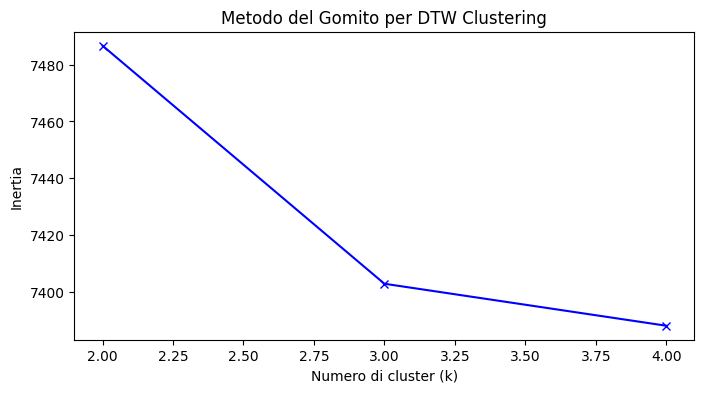

In [88]:
from tslearn.clustering import TimeSeriesKMeans
import numpy as np
import time
import matplotlib.pyplot as plt

# ---- 1. Parametri Light ----
max_iter = 5 
n_init = 1
k_values = [2, 3, 4] 

results_inertia = []
models = {}

print("Inizio Clustering DTW Ultra-Rapido...")

# ---- 2. Loop di Clustering ----
for k in k_values:
    start_time = time.time()
    
    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        metric_params={"sakoe_chiba_radius": 0.05},
        max_iter=max_iter,
        n_init=n_init,
        random_state=42,
        n_jobs=-1 # Usa tutti i core della CPU
    )

    labels = km.fit_predict(X_clustering_scaled)
    duration = time.time() - start_time
    
    # L'Inertia è già calcolata dal modello alla fine di fit_predict
    inertia = km.inertia_
    results_inertia.append(inertia)
    models[k] = labels

    print(f"k={k} | Inertia: {inertia:.2f} | Tempo: {duration:.1f}s")

# ---- 3. Visualizzazione "Gomito" (Elbow Method) ----
plt.figure(figsize=(8, 4))
plt.plot(k_values, results_inertia, 'bx-')
plt.xlabel('Numero di cluster (k)')
plt.ylabel('Inertia')
plt.title('Metodo del Gomito per DTW Clustering')
plt.show()

In [89]:
# Scegli il k basandoti sul grafico del gomito
k_scelto = 3

# Recuperiamo le etichette salvate senza ricalcolare nulla
cl_dtw = models[k_scelto]

print(f"Risultati estratti per k={k_scelto}")
print(f"Distribuzione campioni nei cluster: {np.bincount(cl_dtw)}")

Risultati estratti per k=3
Distribuzione campioni nei cluster: [164 110 174]


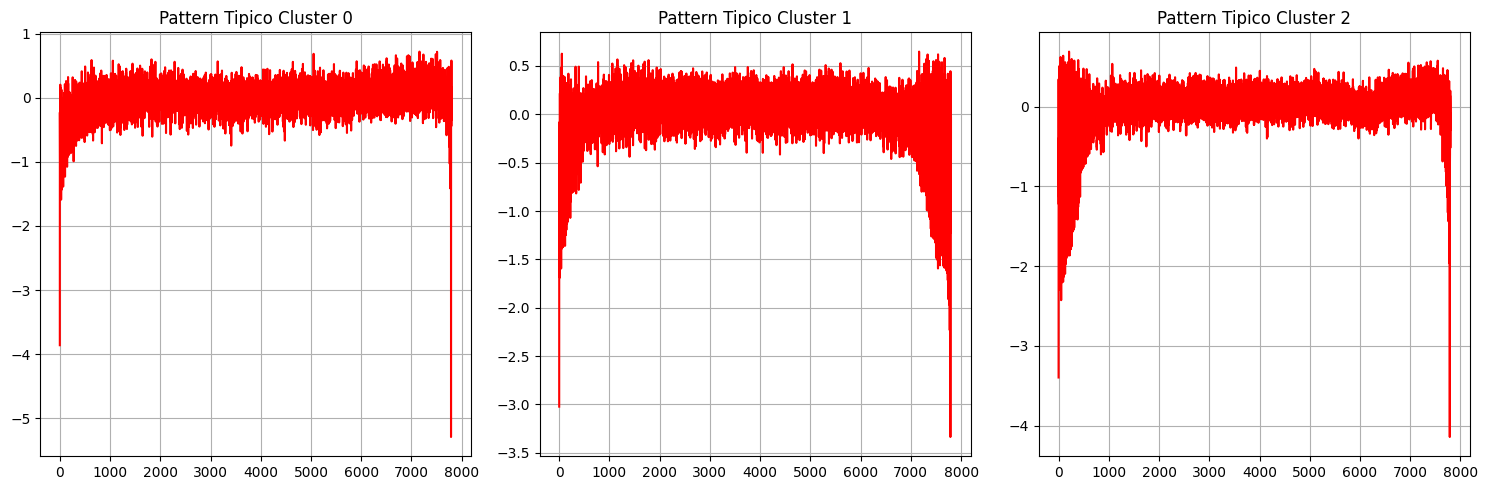

In [90]:
import matplotlib.pyplot as plt

# Recuperiamo il modello KMeans specifico per il k scelto
# Nota: dovremmo aver salvato l'oggetto modello nel loop precedente
# Aggiorna il loop precedente aggiungendo: models_obj[k] = km

plt.figure(figsize=(15, 5))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    # Prendiamo il centroide (il "pattern tipo") del cluster i
    # km_dtw_final deve essere il modello fittato con k_scelto
    centroid = km.cluster_centers_[i] 
    plt.plot(centroid.ravel(), "r-")
    plt.title(f"Pattern Tipico Cluster {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()

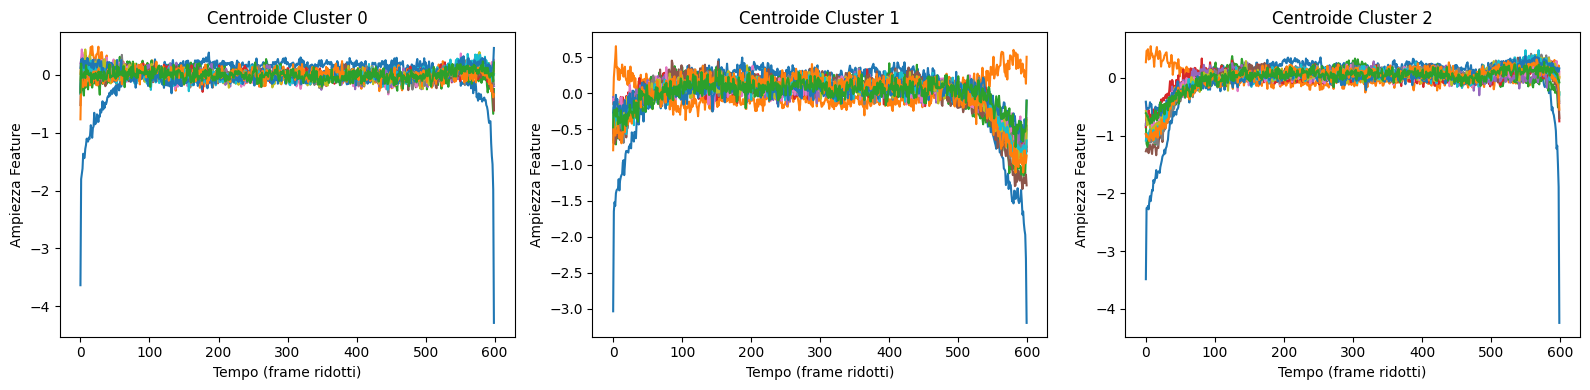

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    
    # Estraiamo i dati del cluster i (usando X_fast che è quello del clustering)
    cluster_data = X_clustering_scaled[cl_dtw == i]
    
    # Calcoliamo il centroide medio per questo cluster
    centroid = cluster_data.mean(axis=0)
    
    plt.plot(centroid)
    plt.title(f"Centroide Cluster {i}")
    plt.xlabel("Tempo (frame ridotti)")
    plt.ylabel("Ampiezza Feature")

plt.tight_layout()
plt.show()

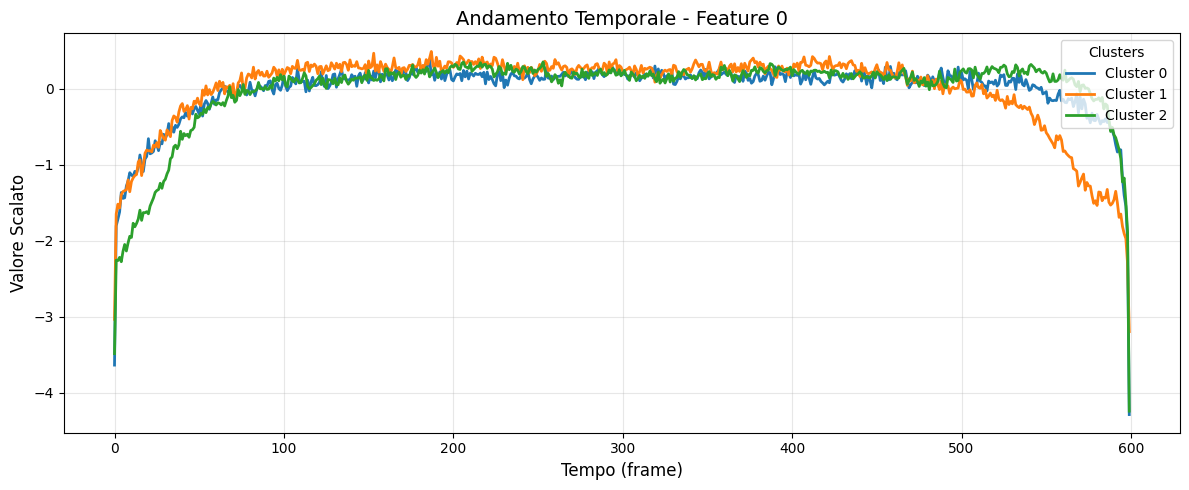

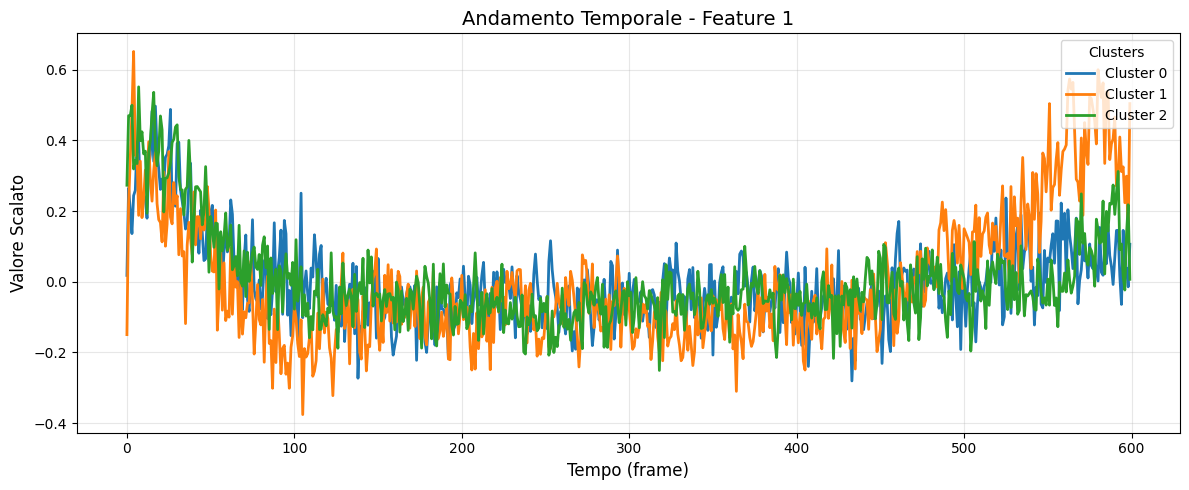

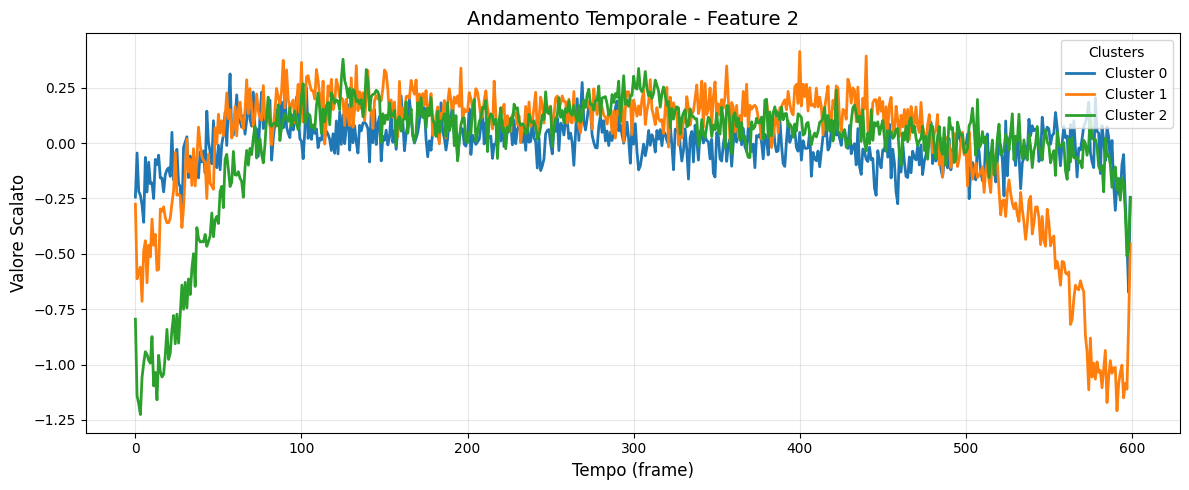

In [94]:
import matplotlib.pyplot as plt

feature_indices = [0, 1, 2]  # Le feature che vuoi analizzare
k_scelto = len(np.unique(cl_dtw)) # Recupera il numero di cluster

for j in feature_indices:
    # Creiamo una nuova figura per ogni feature
    plt.figure(figsize=(12, 5))
    
    # Iteriamo su ogni cluster
    for i in range(k_scelto):
        # Estraiamo i dati del cluster i
        cluster_data = X_clustering_scaled[cl_dtw == i]
        
        if len(cluster_data) > 0:
            # Calcoliamo il centroide (media dei brani nel cluster)
            # cluster_data è (n_brani, tempo, feature) -> mean(axis=0) è (tempo, feature)
            centroid = cluster_data.mean(axis=0)
            
            # Selezioniamo SOLO la feature j corrente
            plt.plot(centroid[:, j], label=f"Cluster {i}", linewidth=2)

    # Personalizzazione del grafico della feature j
    plt.title(f"Andamento Temporale - Feature {j}", fontsize=14)
    plt.xlabel("Tempo (frame)", fontsize=12)
    plt.ylabel("Valore Scalato", fontsize=12)
    plt.legend(loc='upper right', title="Clusters")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show() # Mostra il grafico della feature j prima di passare alla prossima

In [95]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo una copia per l'analisi: df_processed resta pulito
df_analysis = df_processed.copy()
df_analysis['cluster'] = cl_dtw  # Aggiungiamo i cluster solo alla copia

# 1. PCA: Appiattiamo X_clustering (454, 150, 20) -> (454, 3000)
X_flat = X_clustering_scaled.reshape(X_clustering_scaled.shape[0], -1)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

# Aggiungiamo le coordinate PCA alla copia per il plotting
df_analysis['pca_1'] = X_pca[:, 0]
df_analysis['pca_2'] = X_pca[:, 1]

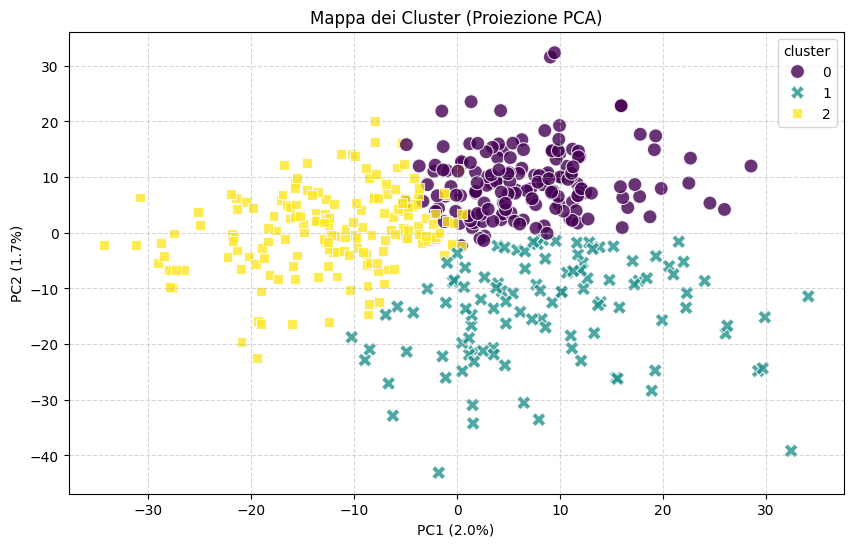

In [96]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analysis, 
    x='pca_1', y='pca_2', 
    hue='cluster', 
    palette='viridis',
    style='cluster',
    s=100, alpha=0.8
)
plt.title("Mappa dei Cluster (Proiezione PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

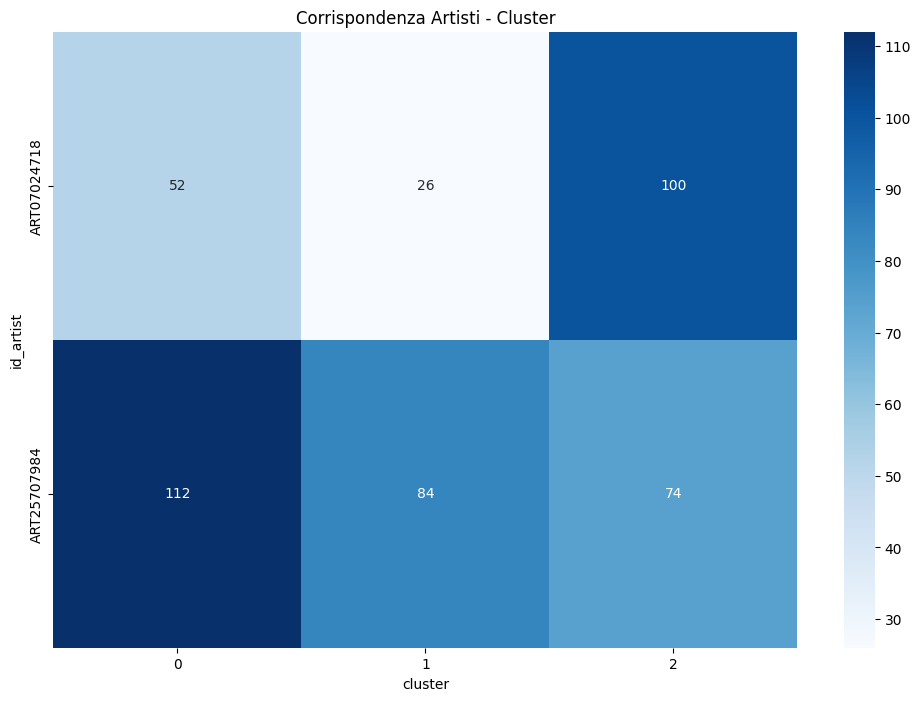

Cluster 0: L'artista più presente è 'ART25707984' (112 brani).
Cluster 1: L'artista più presente è 'ART25707984' (84 brani).
Cluster 2: L'artista più presente è 'ART07024718' (100 brani).


In [97]:
# Creiamo la tabella di contingenza (Artisti vs Cluster)
artist_ctab = pd.crosstab(df_analysis['id_artist'], df_analysis['cluster'])

# Visualizzazione con Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(artist_ctab, annot=True, fmt='d', cmap="Blues")
plt.title("Corrispondenza Artisti - Cluster")
plt.show()

# Identifichiamo l'artista "simbolo" di ogni cluster
for c in sorted(df_analysis['cluster'].unique()):
    top_art = artist_ctab[c].idxmax()
    count = artist_ctab[c].max()
    print(f"Cluster {c}: L'artista più presente è '{top_art}' ({count} brani).")

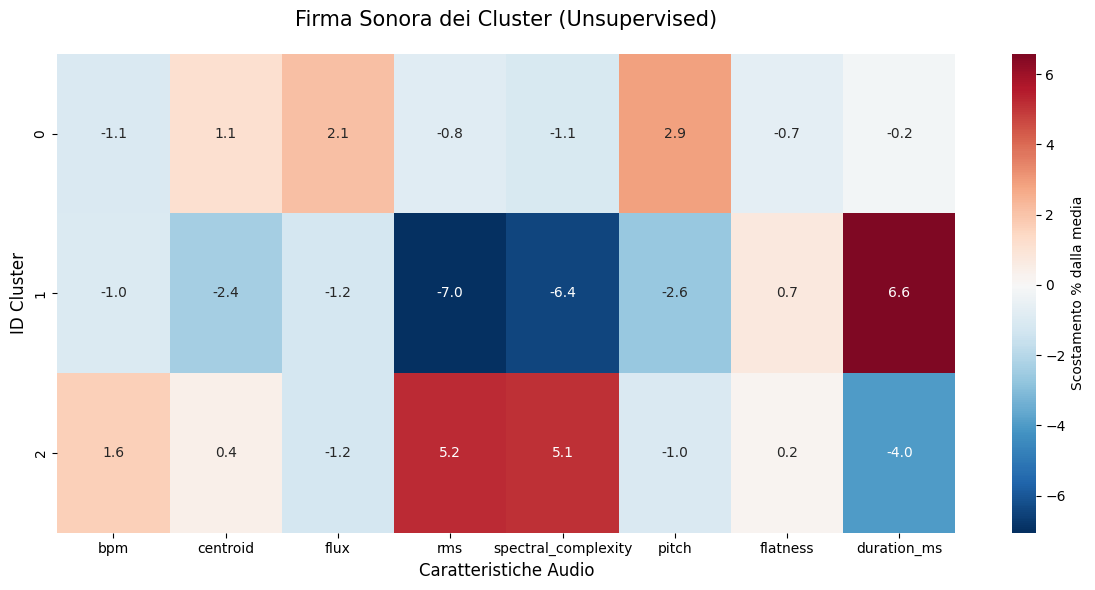

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepariamo i dati (usando la copia per non sporcare df_processed)
df_analysis = df_processed.copy()
df_analysis['Cluster'] = cl_dtw

# 2. Calcoliamo lo scostamento percentuale rispetto alla media globale
cluster_means = df_analysis.groupby('Cluster')[AUDIO_COLS].mean()
global_means = df_analysis[AUDIO_COLS].mean()
relative_diff = (cluster_means / global_means - 1) * 100

# 3. Creazione della Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    relative_diff, 
    annot=True,              # Mostra i numeri dentro le celle
    fmt=".1f",               # Un decimale
    cmap="RdBu_r",           # Blu per valori bassi, Rosso per alti, Bianco per la media
    center=0,                # Il bianco rappresenta lo 0 (la media globale)
    cbar_kws={'label': 'Scostamento % dalla media'}
)

plt.title("Firma Sonora dei Cluster (Unsupervised)", fontsize=15, pad=20)
plt.ylabel("ID Cluster", fontsize=12)
plt.xlabel("Caratteristiche Audio", fontsize=12)
plt.tight_layout()
plt.show()

## Euclidian

Inizio Clustering (Euclidean) con valutazione Silhouette...
k=2 | Inertia: 15056.07 | Silhouette: 0.010 | Tempo: 10.6s
k=3 | Inertia: 14968.60 | Silhouette: 0.007 | Tempo: 12.2s
k=4 | Inertia: 14875.78 | Silhouette: 0.008 | Tempo: 10.2s
k=5 | Inertia: 14837.31 | Silhouette: 0.003 | Tempo: 21.1s
k=6 | Inertia: 14799.69 | Silhouette: 0.005 | Tempo: 11.5s
k=7 | Inertia: 14769.73 | Silhouette: 0.004 | Tempo: 9.9s


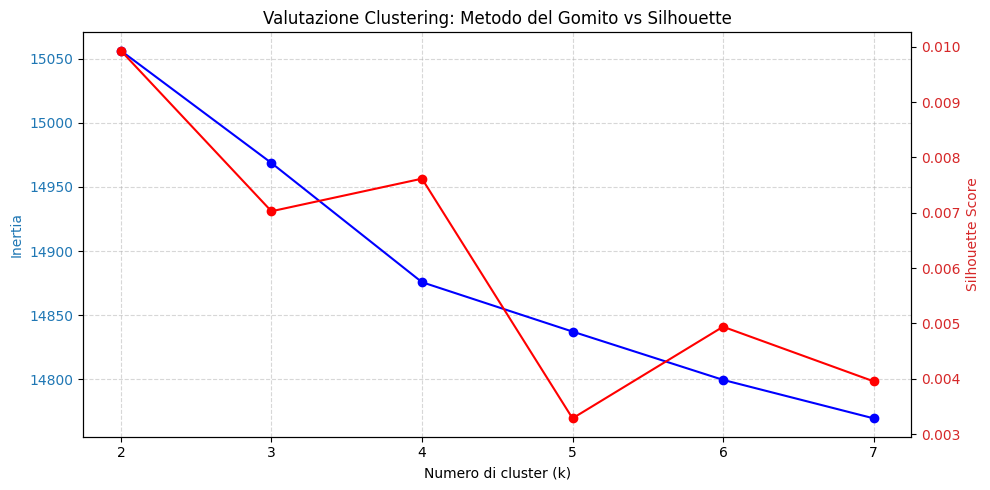

In [147]:
from tslearn.clustering import TimeSeriesKMeans, silhouette_score
import numpy as np
import time
import matplotlib.pyplot as plt

# ---- 1. Parametri ----
max_iter = 10 # Aumentato leggermente per stabilità
n_init = 2    # Aumentato per evitare minimi locali "sfortunati"
k_values = [2, 3, 4, 5, 6, 7] 

results_inertia = []
results_silhouette = []
models = {}

print("Inizio Clustering (Euclidean) con valutazione Silhouette...")

# ---- 2. Loop di Clustering ----
for k in k_values:
    start_time = time.time()
    
    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="euclidean", 
        max_iter=max_iter,
        n_init=n_init,
        random_state=42,
        n_jobs=-1
    )

    labels = km.fit_predict(X_scaled)
    duration = time.time() - start_time
    
    # Metrica 1: Inertia
    inertia = km.inertia_
    results_inertia.append(inertia)
    
    # Metrica 2: Silhouette Score
    # Nota: usiamo X_clustering appiattito per silhouette_score standard se Euclidean
    # oppure silhouette_score di tslearn per coerenza
    score = silhouette_score(X_scaled, labels, metric="euclidean")
    results_silhouette.append(score)
    
    models[k] = labels
    print(f"k={k} | Inertia: {inertia:.2f} | Silhouette: {score:.3f} | Tempo: {duration:.1f}s")

# ---- 3. Doppia Visualizzazione ----
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia (Gomito)
color = 'tab:blue'
ax1.set_xlabel('Numero di cluster (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(k_values, results_inertia, 'bo-', label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot Silhouette (Picco)
ax2 = ax1.twinx() 
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_values, results_silhouette, 'ro-', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Valutazione Clustering: Metodo del Gomito vs Silhouette')
fig.tight_layout()
plt.show()

In [148]:
# Scegli il k basandoti sul grafico del gomito
k_scelto = 4

# Recuperiamo le etichette salvate senza ricalcolare nulla
cl_eu_unsup = models[k_scelto]

print(f"Risultati estratti per k={k_scelto}")
print(f"Distribuzione campioni nei cluster: {np.bincount(cl_eu_unsup)}")

Risultati estratti per k=4
Distribuzione campioni nei cluster: [ 37 177 148  86]


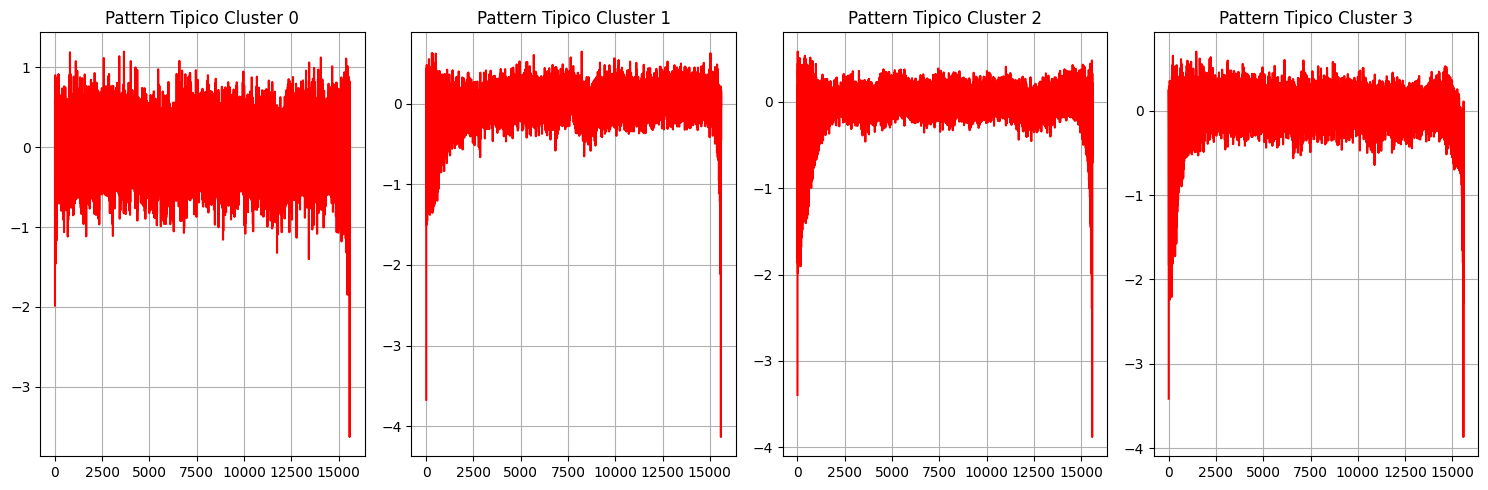

In [149]:
import matplotlib.pyplot as plt

# Recuperiamo il modello KMeans specifico per il k scelto
# Nota: dovremmo aver salvato l'oggetto modello nel loop precedente
# Aggiorna il loop precedente aggiungendo: models_obj[k] = km

plt.figure(figsize=(15, 5))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    # Prendiamo il centroide (il "pattern tipo") del cluster i
    # km_dtw_final deve essere il modello fittato con k_scelto
    centroid = km.cluster_centers_[i] 
    plt.plot(centroid.ravel(), "r-")
    plt.title(f"Pattern Tipico Cluster {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()

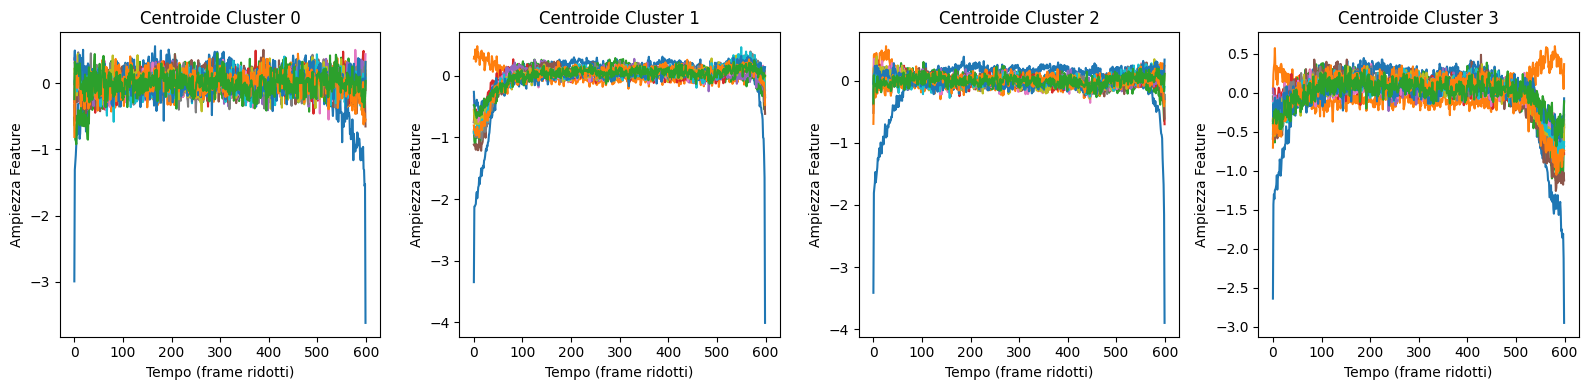

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    
    cluster_data = X_clustering[cl_eu_unsup == i]
    
    # Calcoliamo il centroide medio per questo cluster
    centroid = cluster_data.mean(axis=0)
    
    plt.plot(centroid)
    plt.title(f"Centroide Cluster {i}")
    plt.xlabel("Tempo (frame ridotti)")
    plt.ylabel("Ampiezza Feature")

plt.tight_layout()
plt.show()

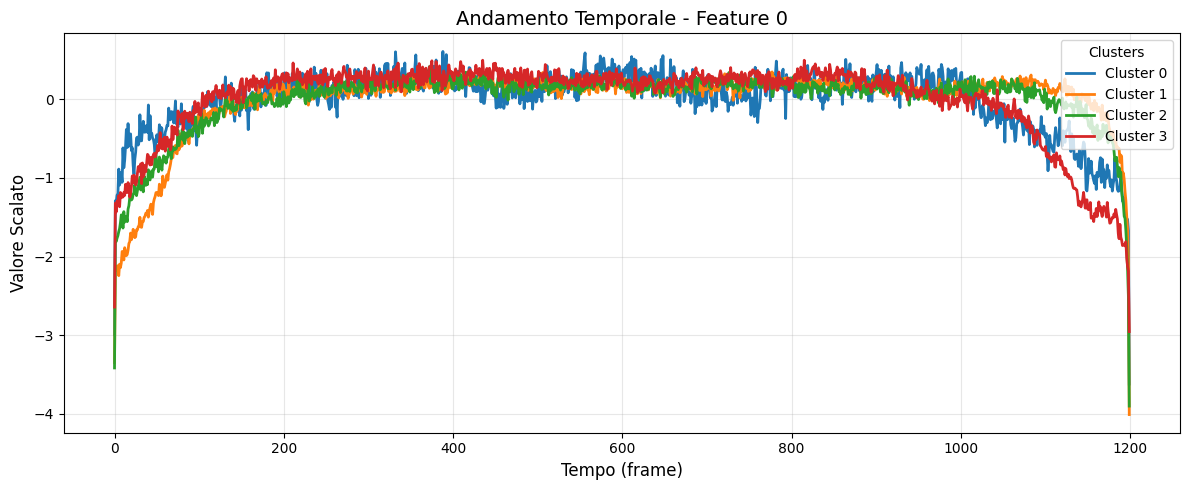

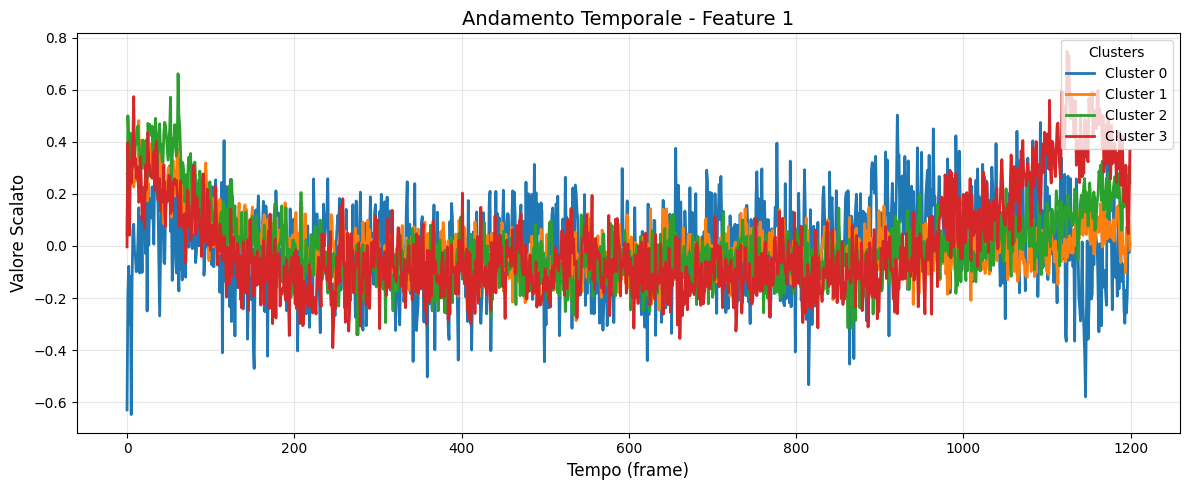

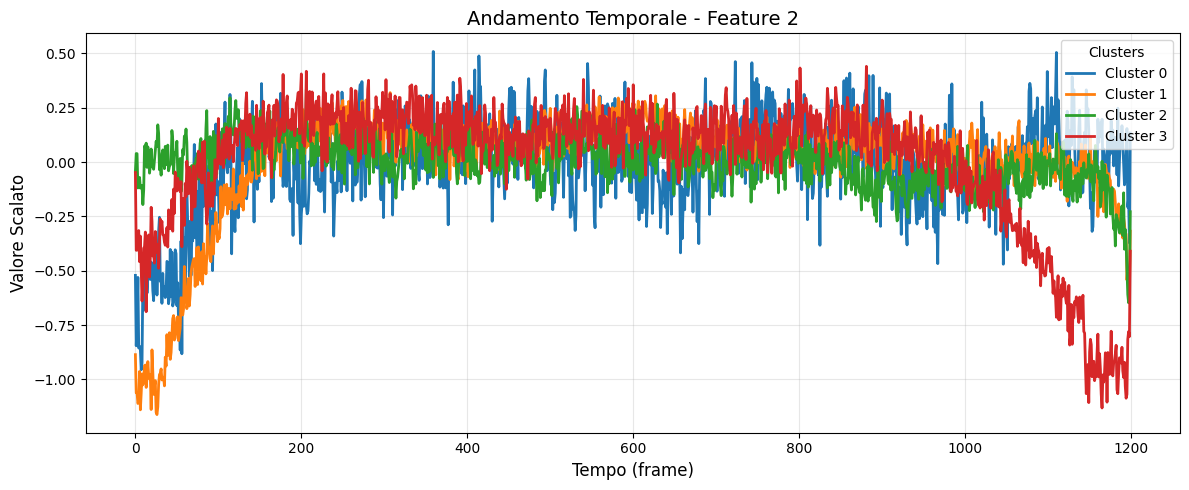

In [151]:
import matplotlib.pyplot as plt

feature_indices = [0, 1, 2]  # Le feature che vuoi analizzare
k_scelto = len(np.unique(cl_eu_unsup)) # Recupera il numero di cluster

for j in feature_indices:
    # Creiamo una nuova figura per ogni feature
    plt.figure(figsize=(12, 5))
    
    # Iteriamo su ogni cluster
    for i in range(k_scelto):
        # Estraiamo i dati del cluster i
        cluster_data = X_scaled[cl_eu_unsup == i]
        
        if len(cluster_data) > 0:
            # Calcoliamo il centroide (media dei brani nel cluster)
            # cluster_data è (n_brani, tempo, feature) -> mean(axis=0) è (tempo, feature)
            centroid = cluster_data.mean(axis=0)
            
            # Selezioniamo SOLO la feature j corrente
            plt.plot(centroid[:, j], label=f"Cluster {i}", linewidth=2)

    # Personalizzazione del grafico della feature j
    plt.title(f"Andamento Temporale - Feature {j}", fontsize=14)
    plt.xlabel("Tempo (frame)", fontsize=12)
    plt.ylabel("Valore Scalato", fontsize=12)
    plt.legend(loc='upper right', title="Clusters")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show() # Mostra il grafico della feature j prima di passare alla prossima

In [155]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo una copia per l'analisi: df_processed resta pulito
df_analysis = df_processed.copy()
df_analysis['cluster_eu_unsup'] = cl_eu_unsup  # Aggiungiamo i cluster solo alla copia

# 1. PCA: Appiattiamo X_clustering (454, 600, 60) -> (454, 3000)
X_flat = X_clustering.reshape(X_clustering.shape[0], -1)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_flat)

# Aggiungiamo le coordinate PCA alla copia per il plotting
df_analysis['pca_1'] = X_pca[:, 0]
df_analysis['pca_2'] = X_pca[:, 1]

df_analysis['pca_3'] = X_pca_3d[:, 2]

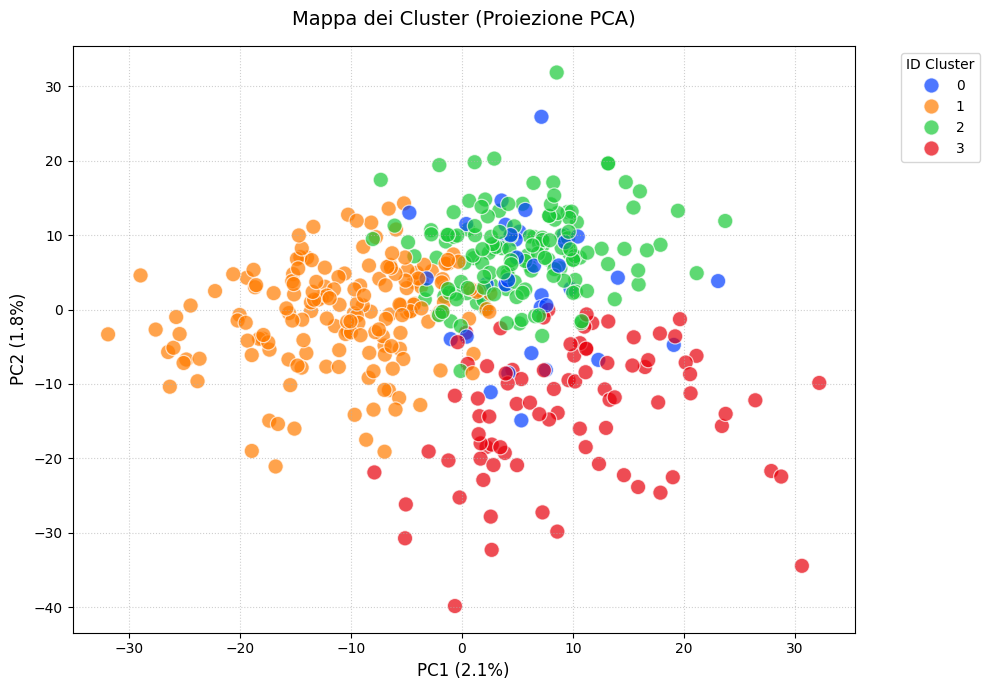

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

# Usiamo una palette più accesa per distinguere bene i 3 cluster
# Palette consigliate: 'bright', 'tab10', 'Set1'
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_analysis, 
    x='pca_1', y='pca_2', 
    hue='cluster_eu_unsup', 
    palette='bright',    # Colori più netti e distinti
    s=120,               # Punti leggermente più grandi
    alpha=0.7,           # Trasparenza per gestire le sovrapposizioni
    edgecolor='w',       # Bordino bianco per far risaltare i punti vicini
    legend='full'
)

plt.title("Mappa dei Cluster (Proiezione PCA)", fontsize=14, pad=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)

# Miglioriamo la legenda
plt.legend(title='ID Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [158]:
import plotly.express as px

fig = px.scatter_3d(
    df_analysis, 
    x='pca_1', y='pca_2', 
    z='pca_3',
    color='cluster_eu_unsup',
    title='3D PCA Plot (Interactive)',
    opacity=0.7,
    size_max=5
)

# Update layout for a cleaner look
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

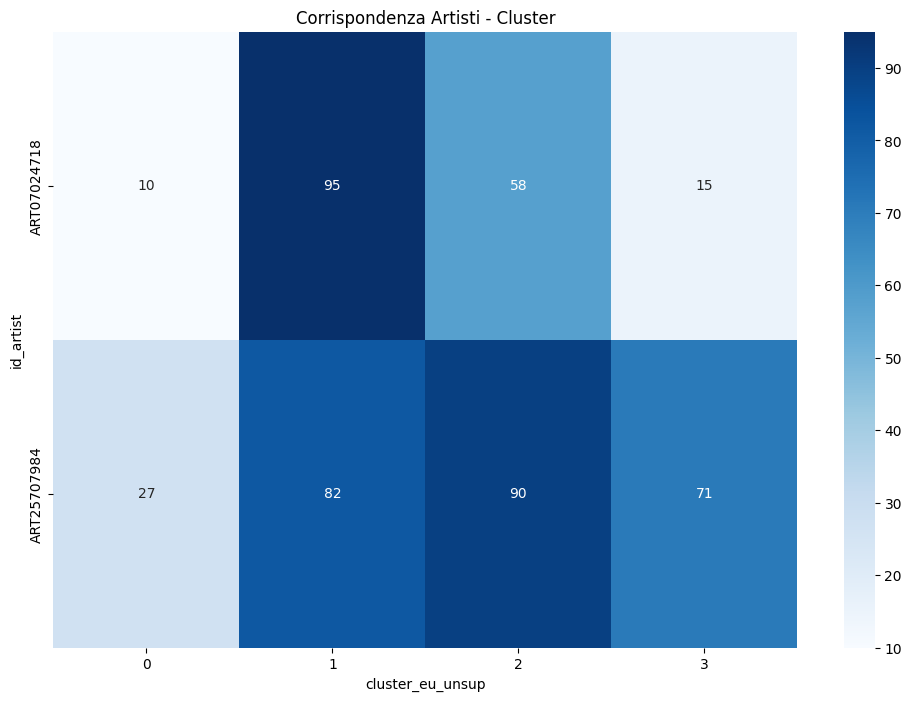

Cluster 0: L'artista più presente è 'ART25707984' (27 brani).
Cluster 1: L'artista più presente è 'ART07024718' (95 brani).
Cluster 2: L'artista più presente è 'ART25707984' (90 brani).
Cluster 3: L'artista più presente è 'ART25707984' (71 brani).


In [160]:
# Creiamo la tabella di contingenza (Artisti vs Cluster)
artist_ctab = pd.crosstab(df_analysis['id_artist'], df_analysis['cluster_eu_unsup'])

# Visualizzazione con Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(artist_ctab, annot=True, fmt='d', cmap="Blues")
plt.title("Corrispondenza Artisti - Cluster")
plt.show()

# Identifichiamo l'artista "simbolo" di ogni cluster
for c in sorted(df_analysis['cluster_eu_unsup'].unique()):
    top_art = artist_ctab[c].idxmax()
    count = artist_ctab[c].max()
    print(f"Cluster {c}: L'artista più presente è '{top_art}' ({count} brani).")

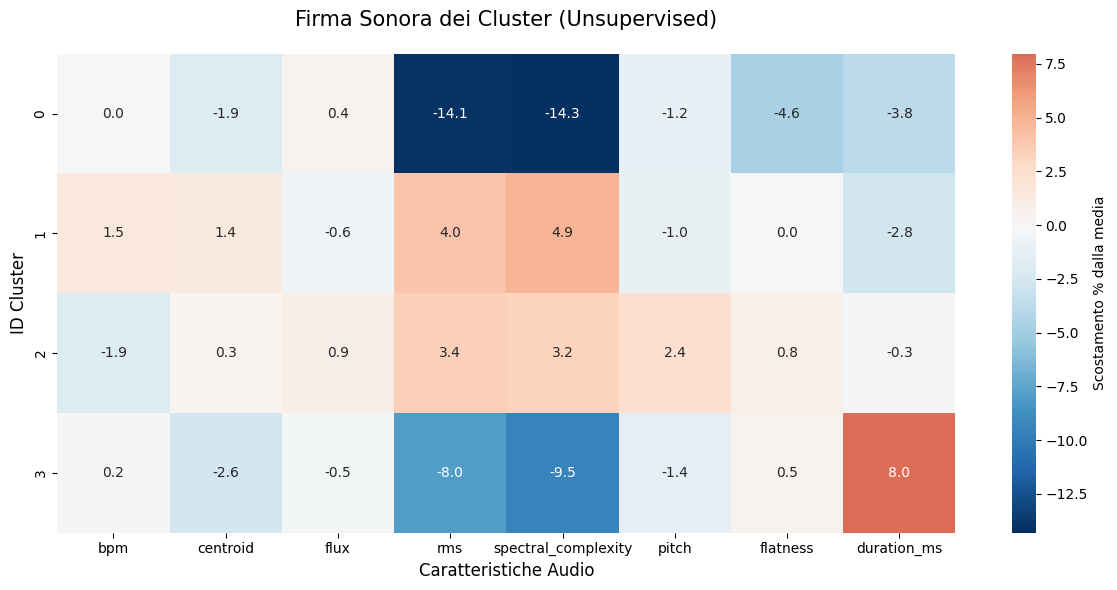

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepariamo i dati (usando la copia per non sporcare df_processed)
df_analysis = df_processed.copy()
df_analysis['cluster_eu_unsup'] = cl_eu_unsup

# 2. Calcoliamo lo scostamento percentuale rispetto alla media globale
cluster_means = df_analysis.groupby('cluster_eu_unsup')[AUDIO_COLS].mean()
global_means = df_analysis[AUDIO_COLS].mean()
relative_diff = (cluster_means / global_means - 1) * 100

# 3. Creazione della Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    relative_diff, 
    annot=True,              # Mostra i numeri dentro le celle
    fmt=".1f",               # Un decimale
    cmap="RdBu_r",           # Blu per valori bassi, Rosso per alti, Bianco per la media
    center=0,                # Il bianco rappresenta lo 0 (la media globale)
    cbar_kws={'label': 'Scostamento % dalla media'}
)

plt.title("Firma Sonora dei Cluster (Unsupervised)", fontsize=15, pad=20)
plt.ylabel("ID Cluster", fontsize=12)
plt.xlabel("Caratteristiche Audio", fontsize=12)
plt.tight_layout()
plt.show()

## Labelled Clustering based on Artist

### Fast DTW

In [117]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesResampler
import numpy as np
import time

max_iter = 5 
n_init = 1
k_values = [2, 3, 4, 5, 6]
unique_artists = sorted(list(set(y_ok)))
artist_to_idx = {name: i for i, name in enumerate(unique_artists)}
y_numeric = np.array([artist_to_idx[name] for name in y_ok])

best_k_dtw = None
best_score_dtw = -1.0
best_cl_dtw = None

print(f"Mappatura: {artist_to_idx}")
print("Inizio Clustering DTW con vincolo Sakoe-Chiba...")

# ---- 3. Loop di Clustering ----
for k in k_values:
    start_time = time.time()
    
    km_dtw = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        metric_params={"sakoe_chiba_radius": 0.05}, # 5% di raggio = 60 frame su 1200
        max_iter=max_iter,
        n_init=n_init,
        random_state=0,
        n_jobs=-1
    )

    cl = km_dtw.fit_predict(X_clustering_scaled)
    
    duration = time.time() - start_time
    print(f"\n[DTW-SAKOE] k={k} completato in {duration:.1f} secondi.")
    
    # ---- Calcolo Purezza ----
    correct = 0
    for c in range(k):
        idx = (cl == c)
        n_c = int(idx.sum())
        
        if n_c > 0:
            counts = np.bincount(y_numeric[idx], minlength=len(unique_artists))
            dom_idx = np.argmax(counts)
            dom_name = unique_artists[dom_idx]
            dom_count = int(counts[dom_idx])
            
            purity = dom_count / n_c
            correct += dom_count
            
            counts_str = " | ".join([f"{unique_artists[i]}={int(counts[i])}" for i in range(len(unique_artists))])
            print(f"   - Cluster {c}: n={n_c} | {counts_str} | dominante={dom_name} | purity={purity:.3f}")
        else:
            print(f"   - Cluster {c}: VUOTO")

    overall_purity = correct / len(cl)
    print(f"Purity totale per k={k}: {overall_purity:.3f}")

    if overall_purity > best_score_dtw:
        best_score_dtw = overall_purity
        best_k_dtw = k
        best_cl_dtw = cl

# ---- 4. Risultati Finali ----
print(f"\n--- DONE ---")
print(f"Miglior k (DTW): {best_k_dtw} con purezza={best_score_dtw:.3f}")

# Salviamo per il confronto con Euclidea
cl_fast_dtw = best_cl_dtw
k_fast_dtw = best_k_dtw

Mappatura: {'ART07024718': 0, 'ART25707984': 1}
Inizio Clustering DTW con vincolo Sakoe-Chiba...


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning:

Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.




[DTW-SAKOE] k=2 completato in 332.8 secondi.
   - Cluster 0: n=213 | ART07024718=53 | ART25707984=160 | dominante=ART25707984 | purity=0.751
   - Cluster 1: n=235 | ART07024718=125 | ART25707984=110 | dominante=ART07024718 | purity=0.532
Purity totale per k=2: 0.636


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning:

Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.



KeyboardInterrupt: 

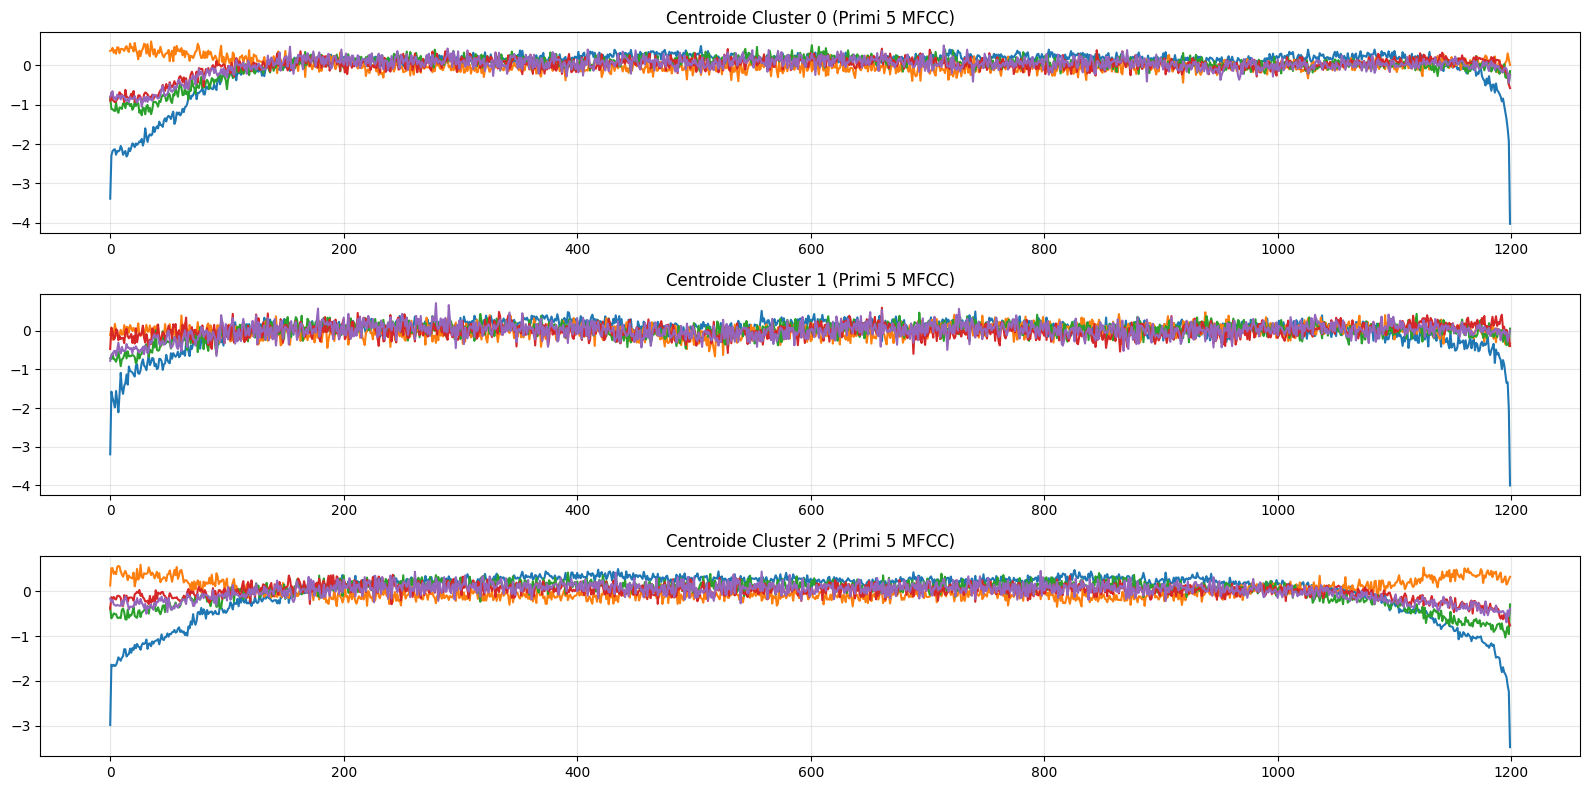

In [20]:
# Visualizzazione dei Centroidi (Serie Temporale Media)
plt.figure(figsize=(16, 8))

# Recuperiamo i centroidi dal modello km_dtw
# Nota: se km_dtw è stato definito dentro il loop, assicurati di usare il modello "best"
# o di rieseguire il fit per il k ottimale.
centroids = km_dtw.cluster_centers_ 

for i in range(k_dtw):
    plt.subplot(k_dtw, 1, i + 1)
    # Mostriamo solo i primi coefficienti MFCC (es. i primi 5) per non sovraffollare
    plt.plot(centroids[i, :, :5]) 
    plt.title(f"Centroide Cluster {i} (Primi 5 MFCC)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Calcolo matrice di distanza DTW per t-SNE...


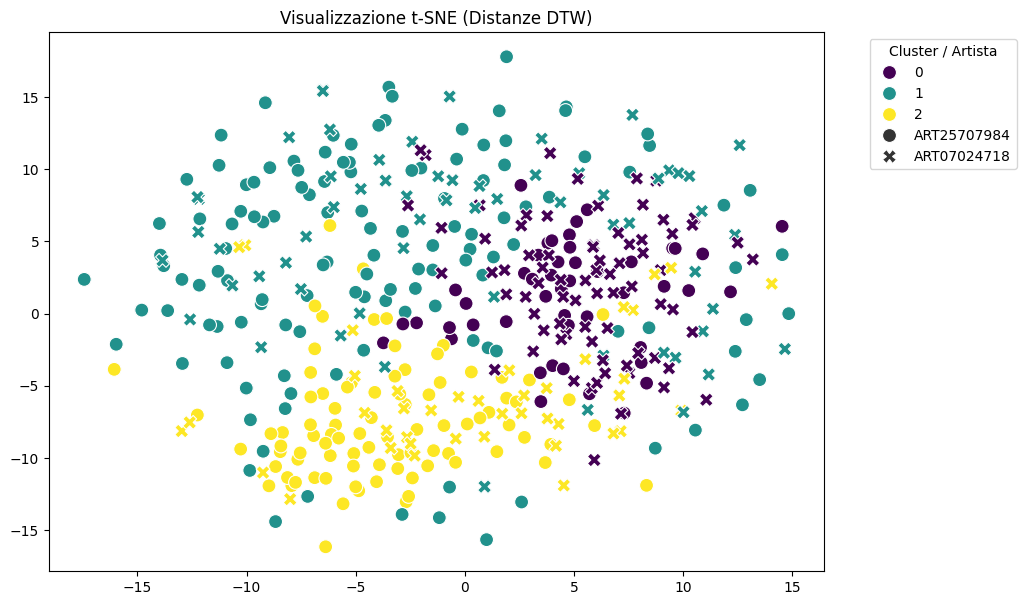

In [22]:
from sklearn.manifold import TSNE
from tslearn.metrics import cdist_dtw

# Attenzione: calcolare la matrice di distanza DTW completa è lento.
# Lo facciamo solo se il dataset non è enorme (454 tracce è ok).
print("Calcolo matrice di distanza DTW per t-SNE...")
dist_matrix = cdist_dtw(X, n_jobs=-1, sakoe_chiba_radius=0.1)

# Applichiamo t-SNE sulla matrice di distanza
tsne = TSNE(n_components=2, metric="precomputed", init="random", random_state=42)
X_embedded = tsne.fit_transform(dist_matrix)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=cl_dtw, style=y_ok, palette='viridis', s=100)
plt.title("Visualizzazione t-SNE (Distanze DTW)")
plt.legend(title="Cluster / Artista", bbox_to_anchor=(1.05, 1))
plt.show()

## Euclidian

In [7]:
from tslearn.clustering import TimeSeriesKMeans
import numpy as np

# ---- Configurazione Clustering ----
L_fast = 1200
max_iter = 10
n_init = 1
k_values = range(2, 5)  # k = 2..6

# 1. Preparazione X (già filtrata e scalata nei passaggi precedenti)
X_fast = X # Usiamo la X già processata a L=1200

# 2. Convertiamo temporaneamente le label stringa in numeri per il calcolo della purezza
# Creiamo una mappatura: Fedez -> 0, Fabri Fibra -> 1 (o viceversa in base ai tuoi dati)
unique_artists = sorted(list(set(y_ok)))
artist_to_idx = {name: i for i, name in enumerate(unique_artists)}
y_numeric = np.array([artist_to_idx[name] for name in y_ok])

print(f"Mappatura per calcolo purezza: {artist_to_idx}")

best_k = None
best_score = -1.0
best_cl = None

# ---- Loop di Clustering ----
for k in k_values:
    km_euc = TimeSeriesKMeans(
        n_clusters=k,
        metric="euclidean",
        max_iter=max_iter,
        n_init=n_init,
        random_state=42
    )

    cl = km_euc.fit_predict(X_fast)

    print(f"\n[EUCLIDEAN-KMeans] k={k} completato.")
    
    correct = 0
    for c in range(k):
        idx = (cl == c)
        n_c = int(idx.sum())
        # Usiamo y_numeric per bincount
        counts = np.bincount(y_numeric[idx], minlength=len(unique_artists)) if n_c else np.zeros(len(unique_artists))
        
        # Identifichiamo l'artista dominante nel cluster
        dom_idx = np.argmax(counts)
        dom_name = unique_artists[dom_idx]
        dom_count = int(counts[dom_idx])
        
        purity = dom_count / n_c if n_c else 0.0
        correct += dom_count

        # Stampa dettagliata (adattata dinamicamente agli artisti presenti)
        counts_str = " | ".join([f"{unique_artists[i]}={int(counts[i])}" for i in range(len(unique_artists))])
        print(f"  - Cluster {c}: n={n_c} | {counts_str} | dominante={dom_name} | purity={purity:.3f}")

    overall_purity = correct / len(cl) if len(cl) else 0.0
    print(f"Purity totale per k={k}: {overall_purity:.3f}")

    if overall_purity > best_score:
        best_score = overall_purity
        best_k = k
        best_cl = cl

print(f"\n[RISULTATO] Miglior k: {best_k} con purezza={best_score:.3f}")

# Variabili finali pronte per l'uso
cl_eu = best_cl
k_eu = best_k

Mappatura per calcolo purezza: {'ART07024718': 0, 'ART25707984': 1}

[EUCLIDEAN-KMeans] k=2 completato.
  - Cluster 0: n=130 | ART07024718=25 | ART25707984=105 | dominante=ART25707984 | purity=0.808
  - Cluster 1: n=324 | ART07024718=154 | ART25707984=170 | dominante=ART25707984 | purity=0.525
Purity totale per k=2: 0.606

[EUCLIDEAN-KMeans] k=3 completato.
  - Cluster 0: n=101 | ART07024718=25 | ART25707984=76 | dominante=ART25707984 | purity=0.752
  - Cluster 1: n=171 | ART07024718=100 | ART25707984=71 | dominante=ART07024718 | purity=0.585
  - Cluster 2: n=182 | ART07024718=54 | ART25707984=128 | dominante=ART25707984 | purity=0.703
Purity totale per k=3: 0.670

[EUCLIDEAN-KMeans] k=4 completato.
  - Cluster 0: n=82 | ART07024718=19 | ART25707984=63 | dominante=ART25707984 | purity=0.768
  - Cluster 1: n=155 | ART07024718=89 | ART25707984=66 | dominante=ART07024718 | purity=0.574
  - Cluster 2: n=145 | ART07024718=53 | ART25707984=92 | dominante=ART25707984 | purity=0.634
  - Cluste

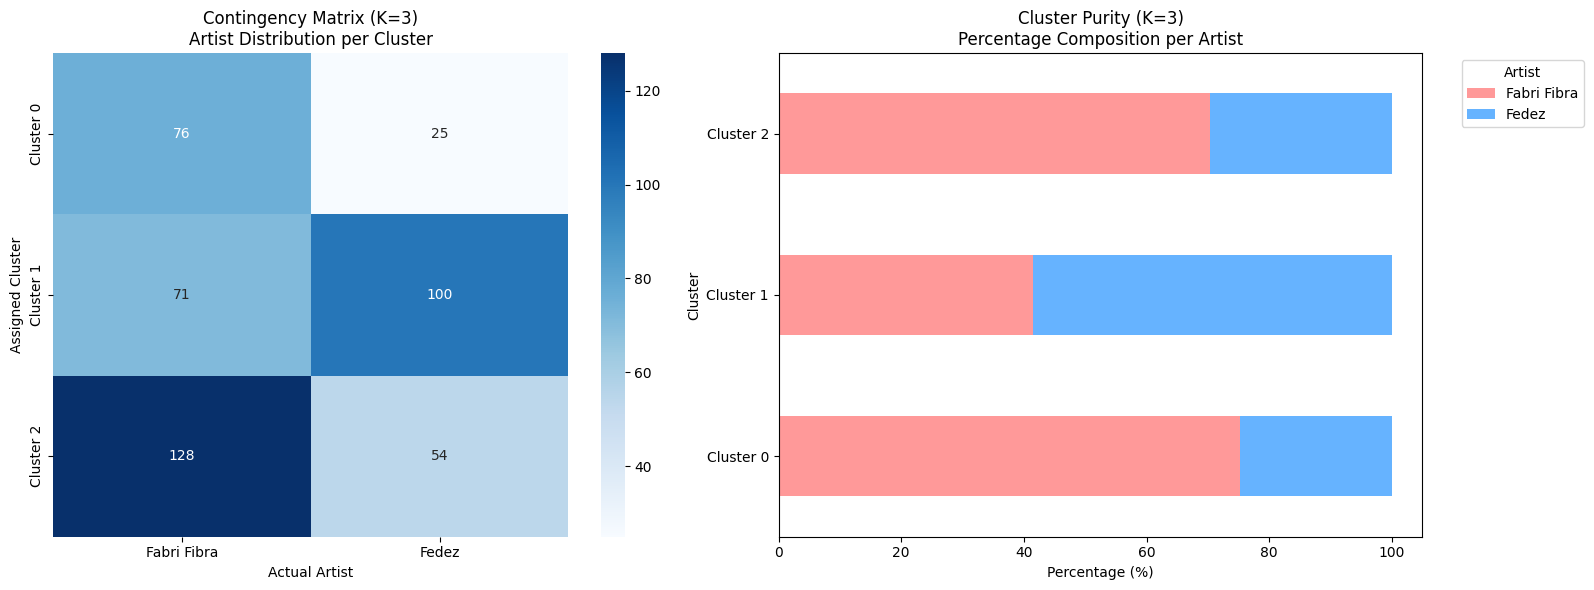

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the artist mapping for readability
ARTIST_MAP = {
    "ART07024718": "Fedez",
    "ART25707984": "Fabri Fibra"
}

# 2. Map the IDs in y_ok to names
artist_names = [ARTIST_MAP.get(name, name) for name in y_ok]

# 3. Create a temporary DataFrame for plotting
plot_df = pd.DataFrame({
    'Cluster': [f'Cluster {c}' for c in cl_eu],
    'Artist': artist_names
})

# 4. Create the Contingency Matrix
contingency_matrix = pd.crosstab(plot_df['Cluster'], plot_df['Artist'])

# --- Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Heatmap (Contingency Matrix)
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Contingency Matrix (K={k_eu})\nArtist Distribution per Cluster')
ax[0].set_ylabel('Assigned Cluster')
ax[0].set_xlabel('Actual Artist')

# PLOT 2: Percentage Composition (Stacked Bar Chart)
contingency_pct = contingency_matrix.div(contingency_matrix.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff9999','#66b3ff'])
ax[1].set_title(f'Cluster Purity (K={k_eu})\nPercentage Composition per Artist')
ax[1].set_xlabel('Percentage (%)')
ax[1].set_ylabel('Cluster')
ax[1].legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [9]:
# 1. Create df_analysis from your processed dataframe
df_analysis = df_processed.copy()

# 2. ATTACH the cluster labels (This solves the KeyError)
df_analysis['cluster_id'] = cl_eu

# 3. Map the Artist IDs to English names for better readability
ARTIST_MAP = {
    "ART07024718": "Fedez",
    "ART25707984": "Fabri Fibra"
}
df_analysis['artist_name'] = df_analysis['id_artist'].map(ARTIST_MAP)

# 4. Filter only tracks belonging to Cluster 1
cluster_1_tracks = df_analysis[df_analysis['cluster_id'] == 1].copy()

print(f"Total tracks in Cluster 1: {len(cluster_1_tracks)}")
print(cluster_1_tracks['artist_name'].value_counts())

Total tracks in Cluster 1: 171
artist_name
Fedez          100
Fabri Fibra     71
Name: count, dtype: int64


In [113]:
from sklearn.metrics.pairwise import cosine_similarity

# Flatten X (Time Series) to compare the 'audio fingerprint'
# X shape (N, 1200, 20) -> (N, 24000)
X_flat = X.reshape(X.shape[0], -1)

# Get the indices of tracks that are in Cluster 1
c1_indices = cluster_1_tracks.index.tolist()
X_c1 = X_flat[c1_indices]

# Calculate similarity only for Cluster 1
sim_matrix_c1 = cosine_similarity(X_c1)

c1_titles = cluster_1_tracks['title'].values
c1_artists = cluster_1_tracks['artist_name'].values

cross_sim_results = []

# Loop through pairs to find cross-artist similarities
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]:
            cross_sim_results.append({
                'song_A': c1_titles[i],
                'artist_A': c1_artists[i],
                'song_B': c1_titles[j],
                'artist_B': c1_artists[j],
                'similarity': sim_matrix_c1[i, j]
            })

# Display top 10 "Twins" (Songs that sound nearly identical across artists)
df_twins = pd.DataFrame(cross_sim_results).sort_values(by='similarity', ascending=False)
df_twins.head(10)

,song_A,artist_A,song_B,artist_B,similarity
6902,Qui Dentro,Fabri Fibra,Che cazzo ridi,Fedez,0.166726
420,Noia,Fabri Fibra,BELLA STRONZA,Fedez,0.160168
3027,El Diablo,Fabri Fibra,MI STO SUL CAZZO,Fedez,0.154829
4477,Adorazione,Fabri Fibra,Questa vita,Fedez,0.150140
6950,Qui Dentro,Fabri Fibra,Nel mio piccolo,Fedez,0.148300
6920,Qui Dentro,Fabri Fibra,BELLA STRONZA,Fedez,0.146243
4361,Meglio Me Che Te,Fabri Fibra,Olivia Oil,Fedez,0.145632
4461,Adorazione,Fabri Fibra,Olivia Oil,Fedez,0.145481
483,Noia,Fabri Fibra,Cambia,Fedez,0.140320
4464,Adorazione,Fabri Fibra,Ti vorrei dire,Fedez,0.138391


In [114]:
# Invece di appiattire tutto (1200*20), calcoliamo la media dei MFCC nel tempo
# Questo trasforma ogni canzone in un profilo medio di 20 valori
X_c1_avg = X[c1_indices].mean(axis=1) # Shape: (N_cluster_1, 20)

# Ora calcoliamo la similarità su questi profili medi
sim_matrix_avg = cosine_similarity(X_c1_avg)

# Ricostruiamo la lista dei "twins"
cross_sim_avg = []
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]:
            cross_sim_avg.append({
                'song_A': c1_titles[i],
                'artist_A': c1_artists[i],
                'song_B': c1_titles[j],
                'artist_B': c1_artists[j],
                'similarity': sim_matrix_avg[i, j]
            })

df_twins_avg = pd.DataFrame(cross_sim_avg).sort_values(by='similarity', ascending=False)
print("Nuova similarità basata su profili medi (Cluster 1):")
print(df_twins_avg.head(10))

Nuova similarità basata su profili medi (Cluster 1):
                                           song_A     artist_A  \
2509                                       Liberi  Fabri Fibra   
402                                          Noia  Fabri Fibra   
1050                                      Playboy  Fabri Fibra   
3931                            Quentin Tarantino  Fabri Fibra   
1020                                      Playboy  Fabri Fibra   
3360                                         6791  Fabri Fibra   
5350                                  Raggi Laser  Fabri Fibra   
2544                                       Liberi  Fabri Fibra   
409                                          Noia  Fabri Fibra   
6172  Tutti In Quarantena (Coronavirus Freestyle)  Fabri Fibra   

               song_B artist_B    similarity  
2509       Cigno nero    Fedez  7.893760e-14  
402    Che cazzo ridi    Fedez  7.671362e-14  
1050  Nel mio piccolo    Fedez  6.727754e-14  
3931   SCELTE STUPIDE    Fedez  

In [115]:
# 1. Calcoliamo la "firma sonora" usando la deviazione standard (texture del suono)
# Invece di .mean(), usiamo .std() che non è influenzato dallo scaler a zero
X_c1_std = X[c1_indices].std(axis=1) 

# 2. Calcolo della similarità
sim_matrix_std = cosine_similarity(X_c1_std)

# 3. Estrazione dei Cross-Artist Twins
cross_sim_std = []
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]:
            cross_sim_std.append({
                'song_A': c1_titles[i],
                'artist_A': c1_artists[i],
                'song_B': c1_titles[j],
                'artist_B': c1_artists[j],
                'similarity': sim_matrix_std[i, j]
            })

df_twins_std = pd.DataFrame(cross_sim_std).sort_values(by='similarity', ascending=False)
print("Similarità basata sulla 'Firma Energetica' (Cluster 1):")
print(df_twins_std.head(10))

Similarità basata sulla 'Firma Energetica' (Cluster 1):
                                           song_A     artist_A  \
4994                Chi Vuole Essere Fabri Fibra?  Fabri Fibra   
2219                             Pronti Al Peggio  Fabri Fibra   
6504                            È Un Tuo Problema  Fabri Fibra   
3986                            Quentin Tarantino  Fabri Fibra   
4780                                 Donna Famosa  Fabri Fibra   
3476                                         Luna  Fabri Fibra   
126                           Non fare la puttana  Fabri Fibra   
6152  Tutti In Quarantena (Coronavirus Freestyle)  Fabri Fibra   
1880                                     Bugiardo  Fabri Fibra   
5508                                     Arrivano  Fabri Fibra   

                        song_B artist_B  similarity  
4994                 Sognatori    Fedez         1.0  
2219           STUPIDO STUPIDO    Fedez         1.0  
6504  ALLUCINAZIONE COLLETTIVA    Fedez         1.0  
3

## Add audio cols

In [117]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# 1. Create a copy of the processed DataFrame
df_analysis = df_processed.copy()

# 2. ATTACH the cluster labels to the DataFrame
# This step fixes the KeyError by creating the 'cluster_id' column
df_analysis['cluster_id'] = cl_eu

# 3. Define the Artist Mapping and metadata columns
ARTIST_MAP = {
    "ART07024718": "Fedez",
    "ART25707984": "Fabri Fibra"
}
df_analysis['artist_name'] = df_analysis['id_artist'].map(ARTIST_MAP)

# List of numeric audio columns to analyze
AUDIO_COLS = [
    'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'flatness', 
    'spectral_complexity', 'pitch', 'duration_ms', 'popularity'
]

# 4. Filter for Cluster 1 (The low-purity/shared style cluster)
df_c1 = df_analysis[df_analysis['cluster_id'] == 1].copy()

print(f"Cluster 1 isolated: {len(df_c1)} tracks found.")

Cluster 1 isolated: 171 tracks found.


In [118]:
# 1. Normalize the metadata features (Min-Max Scaling)
# We handle non-numeric data and fill missing values with 0
scaler = MinMaxScaler()
features_meta = df_c1[AUDIO_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
features_scaled = scaler.fit_transform(features_meta)

# 2. Calculate the Cosine Similarity Matrix
sim_matrix_meta = cosine_similarity(features_scaled)

# 3. Identify Top Cross-Artist "Twins" in Cluster 1
c1_titles = df_c1['title'].values
c1_artists = df_c1['artist_name'].values
c1_ids = df_c1['track_id'].values

meta_sim_list = []
for i in range(len(c1_titles)):
    for j in range(i + 1, len(c1_titles)):
        if c1_artists[i] != c1_artists[j]: # Cross-artist only
            meta_sim_list.append({
                'id_1': c1_ids[i],
                'song_1': c1_titles[i],
                'artist_1': c1_artists[i],
                'id_2': c1_ids[j],
                'song_2': c1_titles[j],
                'artist_2': c1_artists[j],
                'metadata_similarity': sim_matrix_meta[i, j]
            })

# 4. Create the final results DataFrame
df_meta_twins = pd.DataFrame(meta_sim_list).sort_values(by='metadata_similarity', ascending=False)

print("Top 10 Most Similar Cross-Artist Tracks in Cluster 1 (Audio Metadata):")
df_meta_twins.head(10)

Top 10 Most Similar Cross-Artist Tracks in Cluster 1 (Audio Metadata):


,id_1,song_1,artist_1,id_2,song_2,artist_2,metadata_similarity
3954,TR835623,Quentin Tarantino,Fabri Fibra,TR943904,Cosa senza spine,Fedez,0.993884
1236,TR307915,A Me Di Te,Fabri Fibra,TR897360,Polaroid,Fedez,0.993635
3139,TR844218,A Volte,Fabri Fibra,TR731379,Record,Fedez,0.993337
1134,TR150455,Demo Nello Stereo,Fabri Fibra,TR627217,FUORI DAI GUAI,Fedez,0.992910
1212,TR307915,A Me Di Te,Fabri Fibra,TR731111,Faccio brutto,Fedez,0.992114
3957,TR835623,Quentin Tarantino,Fabri Fibra,TR700059,Non ci pensi mai,Fedez,0.991596
1234,TR307915,A Me Di Te,Fabri Fibra,TR627217,FUORI DAI GUAI,Fedez,0.991244
5266,TR975085,Tutti In Campana,Fabri Fibra,TR490859,Voglio averti account,Fedez,0.991169
2654,TR448308,Lascia Un Segno,Fabri Fibra,TR943904,Cosa senza spine,Fedez,0.991066
2467,TR878128,Potevi Essere Tu,Fabri Fibra,TR614818,Non basta mai,Fedez,0.990998


## Motif and anomalies analysis

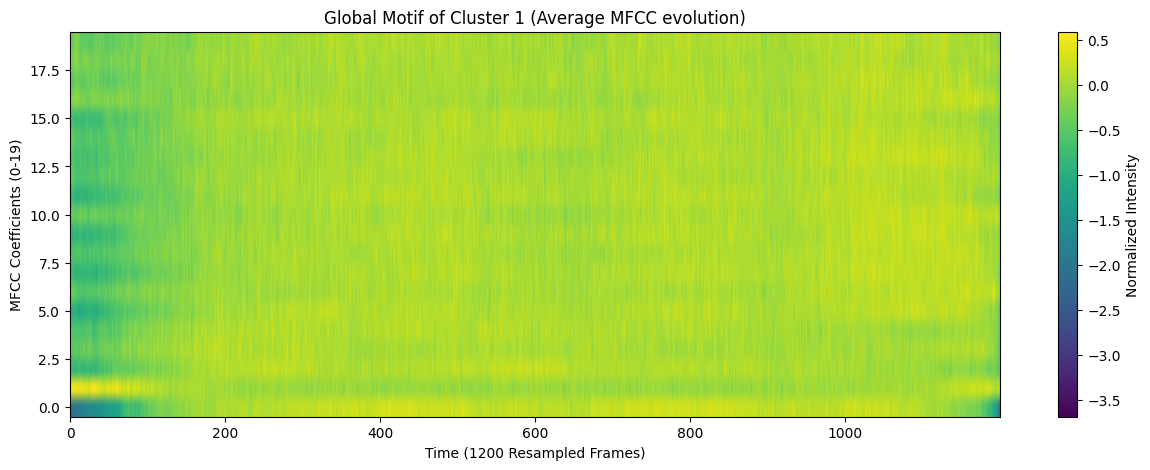

In [119]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify the centroid of Cluster 1
# If you used km_euc in your previous cell:
centroid_1 = km_euc.cluster_centers_[1] 

# 2. Visualize the Temporal Motif (Average MFCC path)
plt.figure(figsize=(15, 5))
plt.imshow(centroid_1.T, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Normalized Intensity')
plt.title("Global Motif of Cluster 1 (Average MFCC evolution)")
plt.xlabel("Time (1200 Resampled Frames)")
plt.ylabel("MFCC Coefficients (0-19)")
plt.show()

In [120]:
from sklearn.metrics import pairwise_distances_argmin_min

# 1. Isolate MFCCs for tracks in Cluster 1
c1_indices = df_analysis[df_analysis['cluster_id'] == 1].index.tolist()
X_c1 = X[c1_indices]

# 2. Find the track closest to the centroid (The Medoid)
# We flatten X_c1 and the centroid for distance calculation
X_c1_flat = X_c1.reshape(len(X_c1), -1)
centroid_flat = centroid_1.flatten().reshape(1, -1)

closest_idx, _ = pairwise_distances_argmin_min(centroid_flat, X_c1_flat)
proto_track_idx = c1_indices[closest_idx[0]]

# 3. Retrieve the "Motif Leader"
proto_track = df_analysis.loc[proto_track_idx]
print(f"The 'Prototypical Motif' of Cluster 1 is represented by:")
print(f"Artist: {proto_track['artist_name']} | Song: {proto_track['title']}")

The 'Prototypical Motif' of Cluster 1 is represented by:
Artist: Fabri Fibra | Song: Tutti In Quarantena (Coronavirus Freestyle)


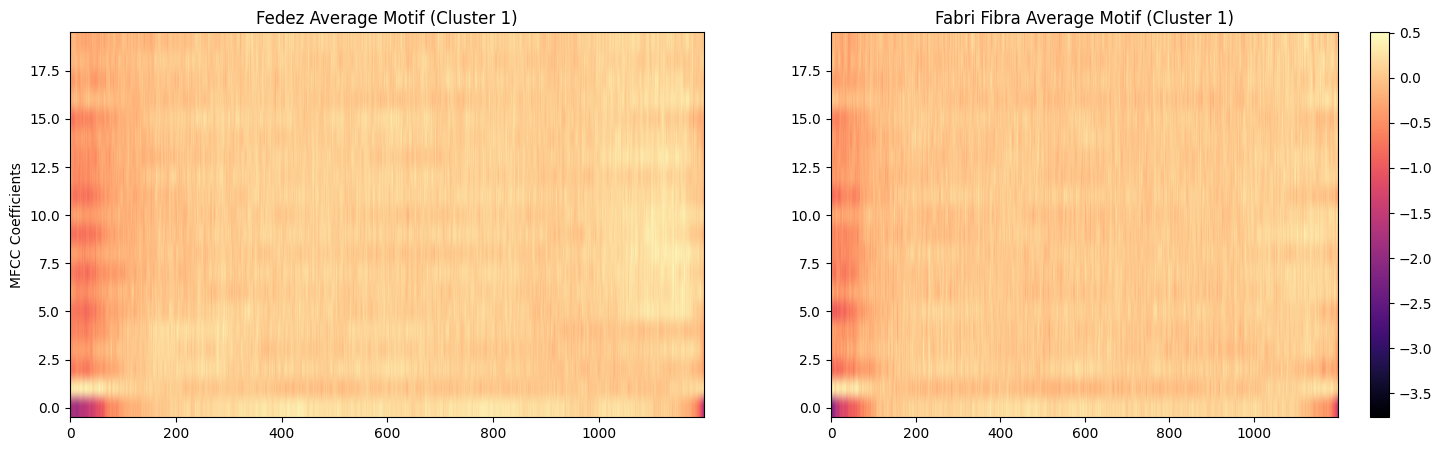

In [31]:
# Separate tracks by artist within Cluster 1
fedez_c1 = X[df_analysis[(df_analysis['cluster_id'] == 1) & (df_analysis['artist_name'] == 'Fedez')].index]
fibra_c1 = X[df_analysis[(df_analysis['cluster_id'] == 1) & (df_analysis['artist_name'] == 'Fabri Fibra')].index]

# Calculate the mean motif for each artist in this cluster
motif_fedez = fedez_c1.mean(axis=0)
motif_fibra = fibra_c1.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

im1 = ax1.imshow(motif_fedez.T, aspect='auto', origin='lower', cmap='magma')
ax1.set_title("Fedez Average Motif (Cluster 1)")
ax1.set_ylabel("MFCC Coefficients")

im2 = ax2.imshow(motif_fibra.T, aspect='auto', origin='lower', cmap='magma')
ax2.set_title("Fabri Fibra Average Motif (Cluster 1)")

plt.colorbar(im2, ax=ax2)
plt.show()

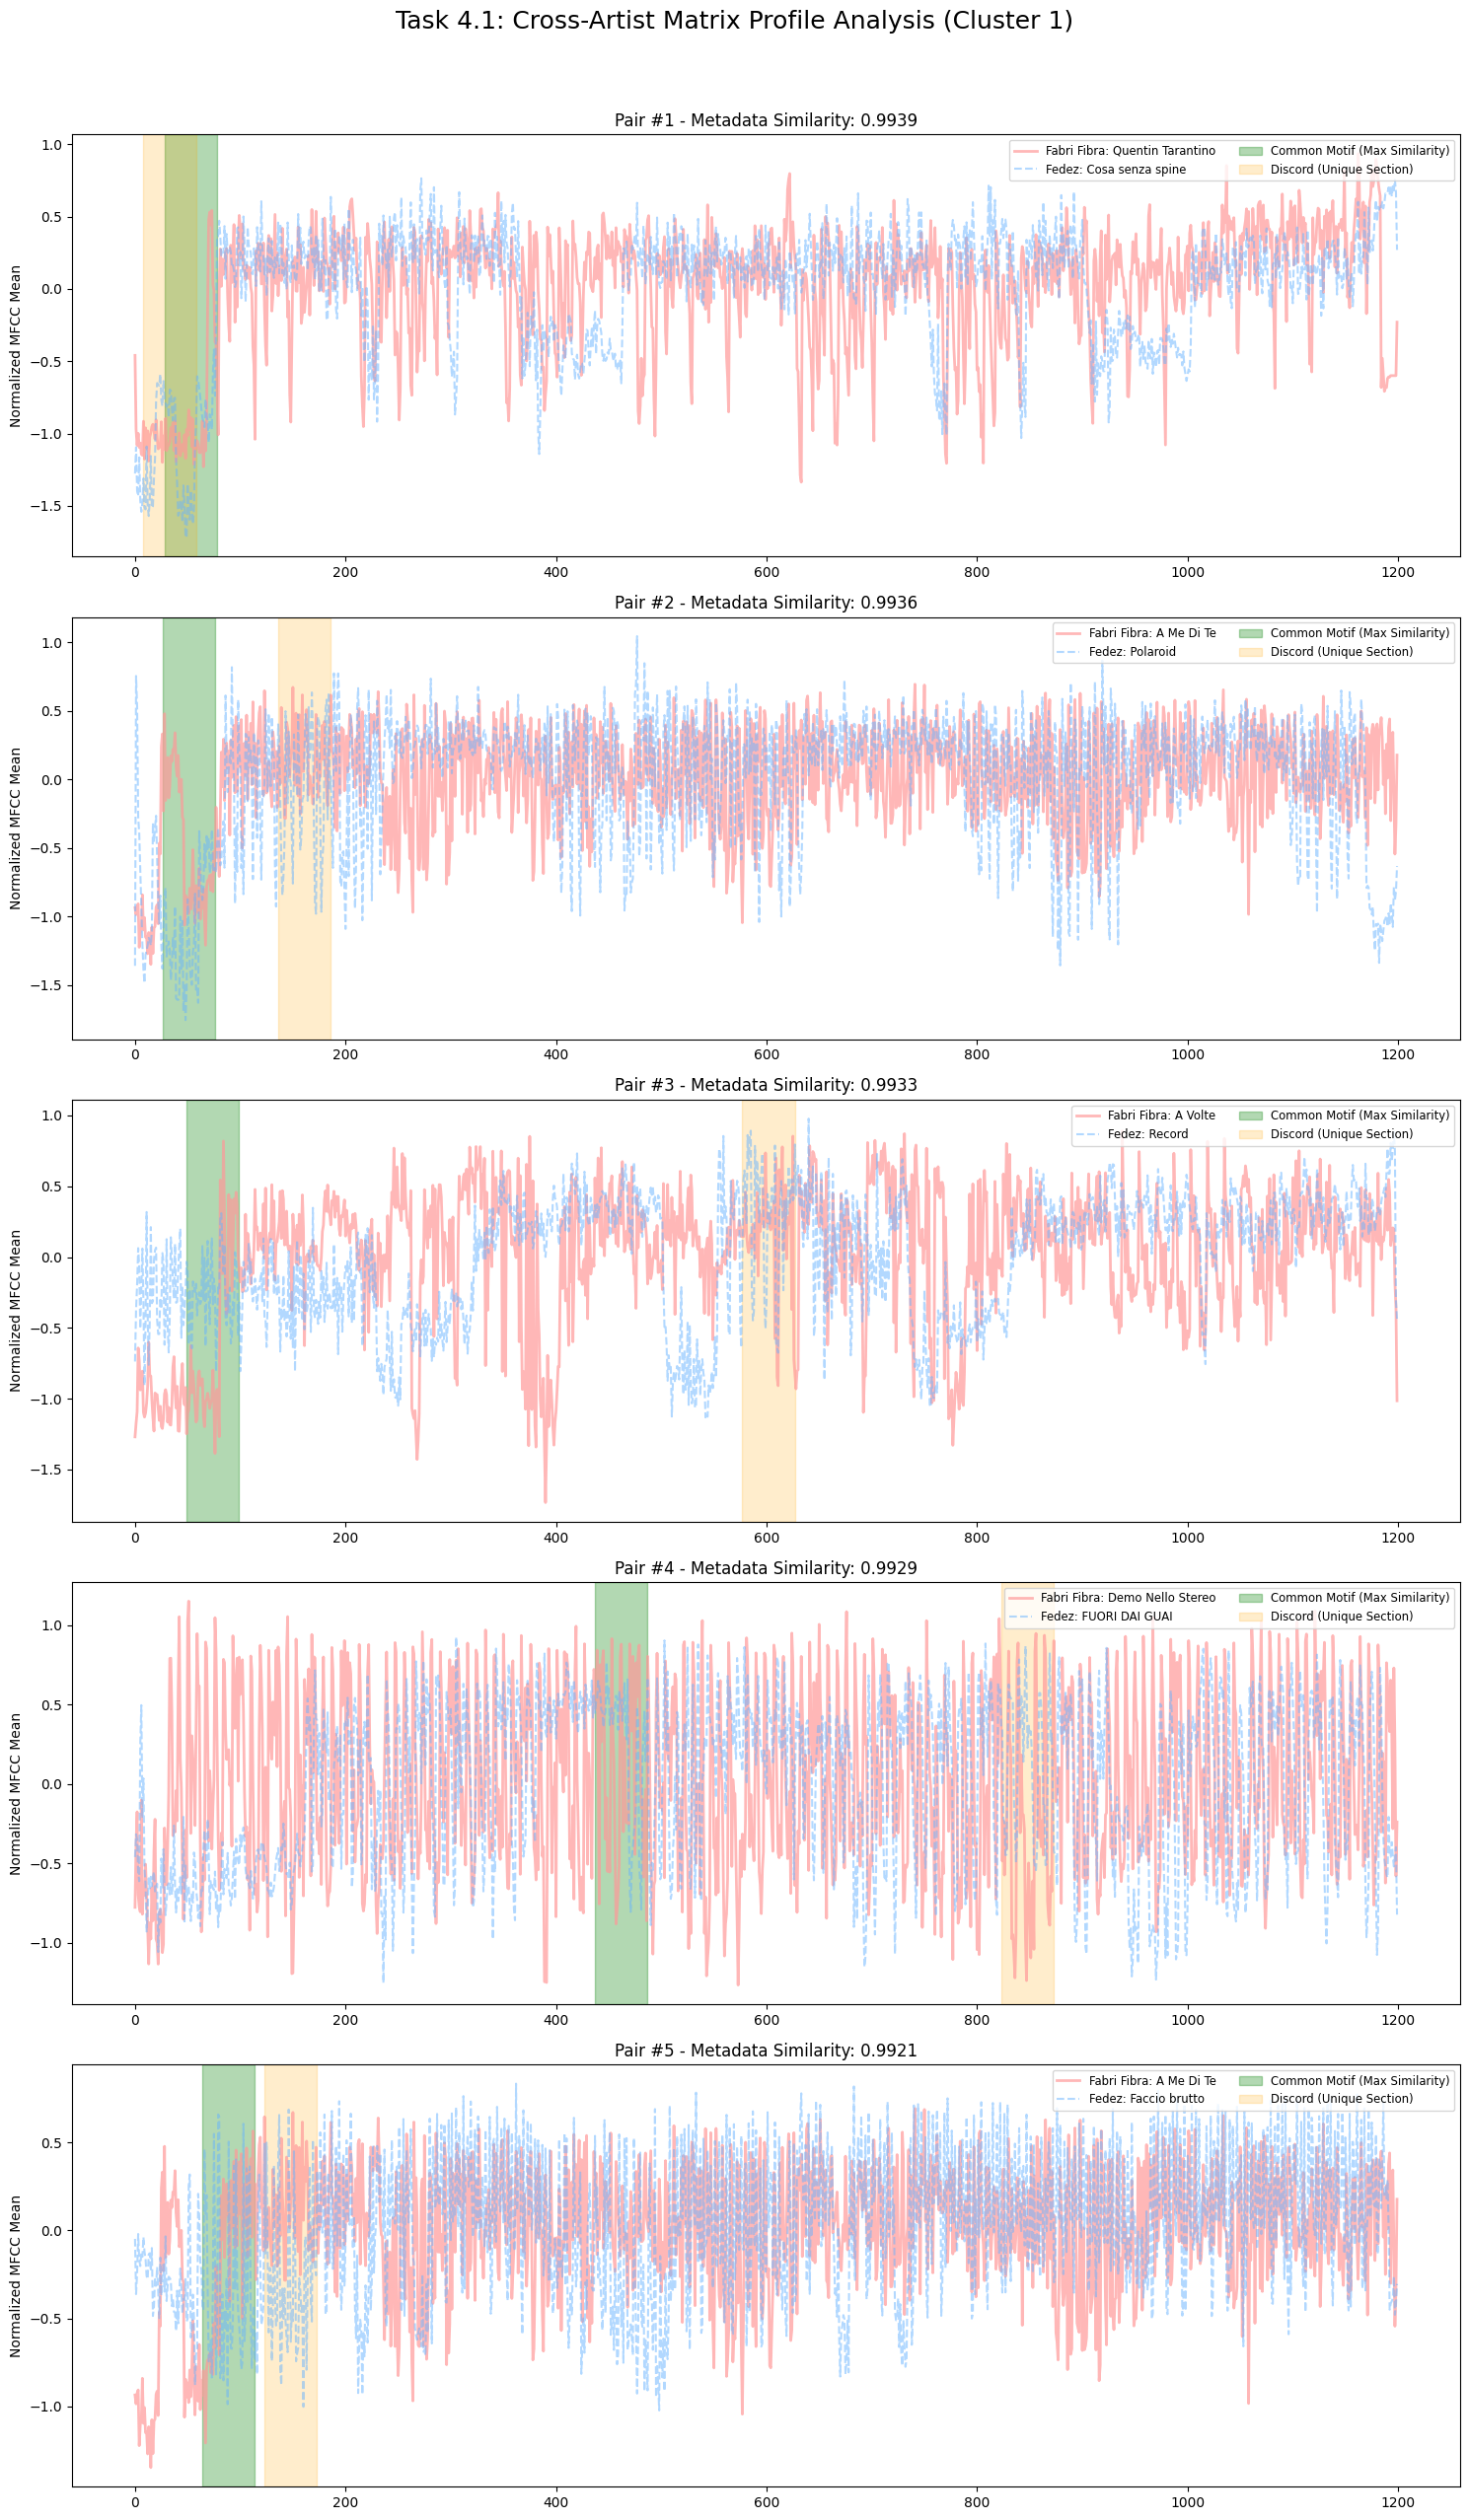

In [121]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

# 1. Select the top 5 matches from the Cluster 1 twins analysis
# We ensure we are using the pairs we found in the neutral cluster
top_matches = df_meta_twins.head(5)

m = 50 # Window size (roughly 1.1 - 2 seconds depending on your hop_length)

fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Task 4.1: Cross-Artist Matrix Profile Analysis (Cluster 1)', fontsize=18, y=1.02)

# Ensure X is float64 for stumpy (it can be picky with float32)
X_stump = X.astype(np.float64)

for i, (index, row) in enumerate(top_matches.iterrows()):
    # Find the numeric index in the X matrix for both songs
    # We use the index from the metadata dataframe to match the X matrix rows
    idx_a = df_analysis[df_analysis['track_id'] == row['id_1']].index[0]
    idx_b = df_analysis[df_analysis['track_id'] == row['id_2']].index[0]
    
    # Extract the signal: averaging the 20 MFCCs to create a 1D "Timbre Stream"
    s_a = X_stump[idx_a, :, :].mean(axis=1)
    s_b = X_stump[idx_b, :, :].mean(axis=1)
    
    # 2. CALCULATE CROSS-MATRIX PROFILE
    # This finds segments in Song A (Fedez) that are most similar to Song B (Fibra)
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b, ignore_trivial=False)
    
    # Motif: The point of lowest distance (maximum similarity)
    idx_a_motif = np.argmin(comp_mp[:, 0])
    # Discord: The point of highest distance (maximum anomaly relative to the other artist)
    idx_a_discord = np.argmax(comp_mp[:, 0])
    
    # 3. VISUALIZATION
    ax = axes[i]
    ax.plot(s_a, label=f"{row['artist_1']}: {row['song_1']}", color='#ff9999', alpha=0.7, lw=2)
    ax.plot(s_b, label=f"{row['artist_2']}: {row['song_2']}", color='#66b3ff', linestyle='--', alpha=0.5)
    
    # Highlight Common Motif (Green)
    ax.axvspan(idx_a_motif, idx_a_motif + m, color='green', alpha=0.3, label='Common Motif (Max Similarity)')
    
    # Highlight Discord (Orange)
    ax.axvspan(idx_a_discord, idx_a_discord + m, color='orange', alpha=0.2, label='Discord (Unique Section)')
    
    ax.set_title(f"Pair #{i+1} - Metadata Similarity: {row['metadata_similarity']:.4f}")
    ax.set_ylabel("Normalized MFCC Mean")
    ax.legend(loc='upper right', fontsize='small', ncol=2)

plt.tight_layout()
plt.show()

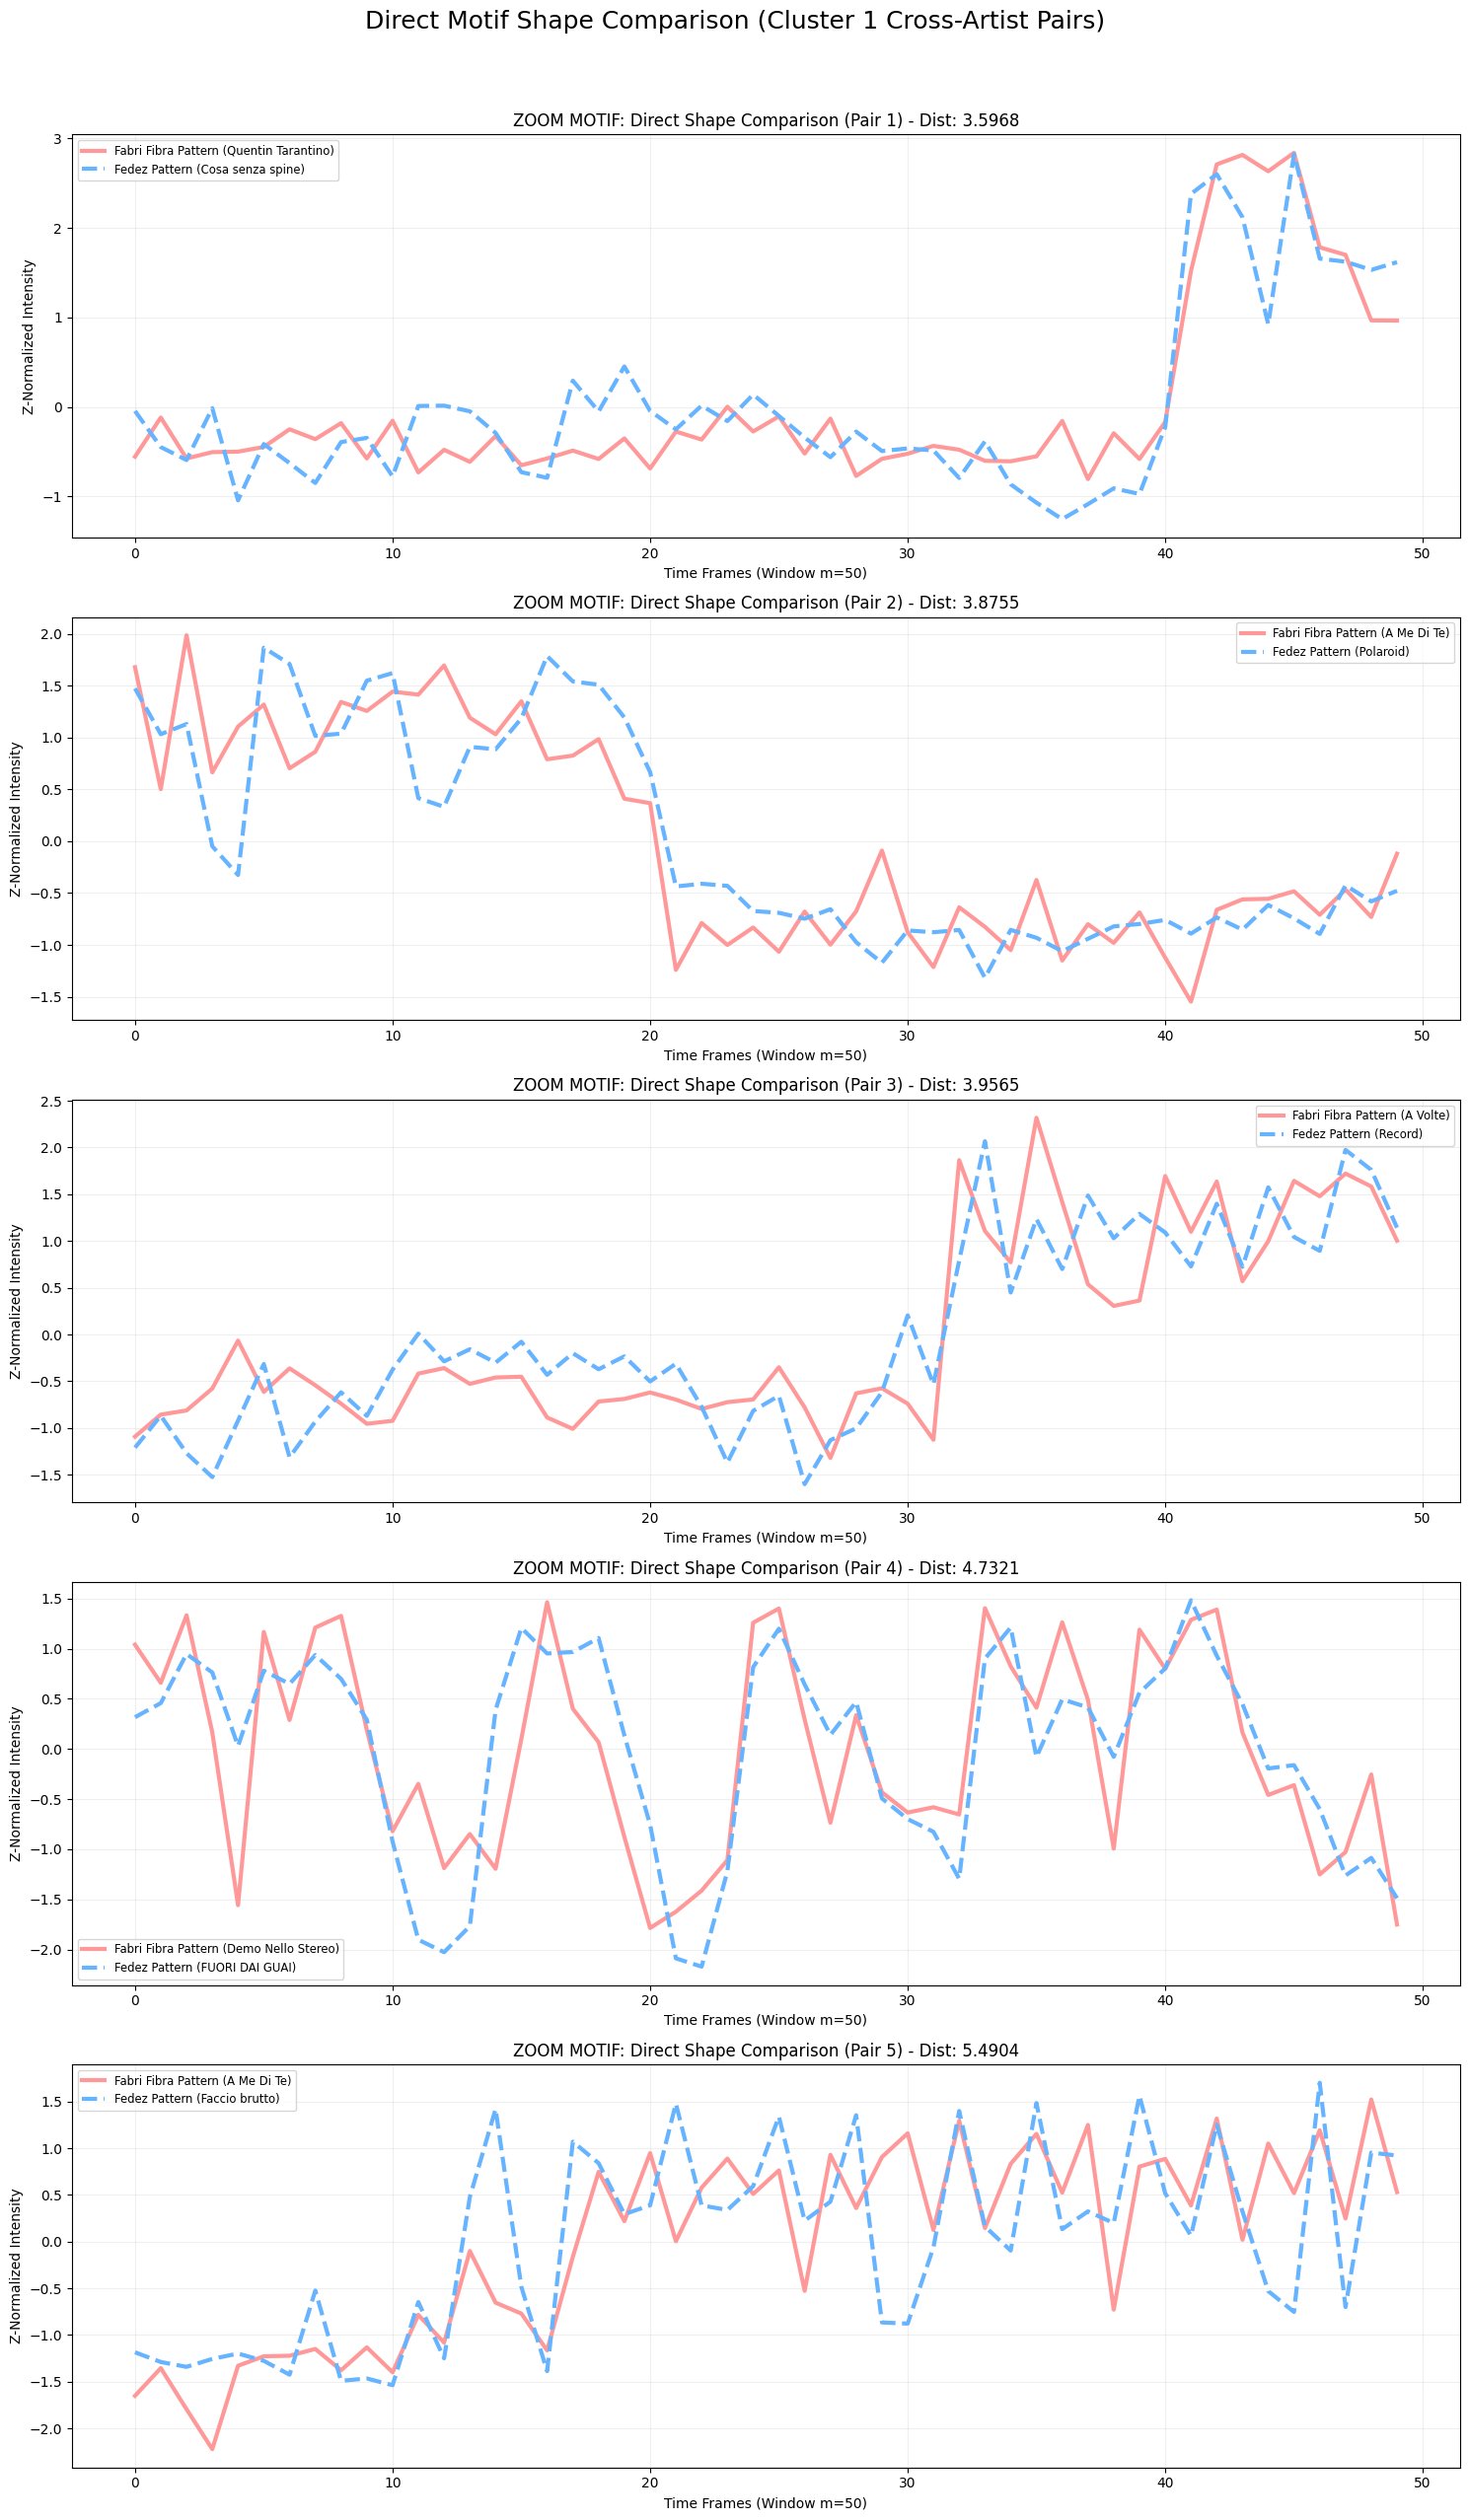

In [122]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

# Using m=50 (approx. 1-2 seconds) to find local patterns
m = 50 
fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Direct Motif Shape Comparison (Cluster 1 Cross-Artist Pairs)', fontsize=18, y=1.02)

# Use the top 5 matches from your metadata twins analysis
for i, (index, row) in enumerate(df_meta_twins.head(5).iterrows()):
    # 1. Retrieve indices for the X matrix
    idx_a = df_analysis[df_analysis['track_id'] == row['id_1']].index[0]
    idx_b = df_analysis[df_analysis['track_id'] == row['id_2']].index[0]
    
    # 2. Extract 1D Time Series (Averaged MFCCs)
    # Ensure float64 for stumpy stability
    s_a = X[idx_a, :, :].mean(axis=1).flatten().astype(float)
    s_b = X[idx_b, :, :].mean(axis=1).flatten().astype(float)
    
    # 3. Calculate Matrix Profile Join (Compare s_a to s_b)
    # This finds the best match for every subsequence in A within B
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b, ignore_trivial=False)
    
    # Identify the starting index of the best motif in A and its match in B
    idx_a_motif = np.argmin(comp_mp[:, 0])
    idx_b_motif = comp_mp[idx_a_motif, 1]
    
    # 4. Extract and Z-Normalize segments to compare SHAPE only
    segment_a = s_a[idx_a_motif : idx_a_motif + m]
    segment_b = s_b[idx_b_motif : idx_b_motif + m]
    
    # Normalization (Standardization) handles different scales
    segment_a_std = (segment_a - np.mean(segment_a)) / np.std(segment_a)
    segment_b_std = (segment_b - np.mean(segment_b)) / np.std(segment_b)
    
    # 5. Plotting
    ax = axes[i]
    ax.plot(segment_a_std, label=f"{row['artist_1']} Pattern ({row['song_1']})", lw=3, color='#ff9999')
    ax.plot(segment_b_std, label=f"{row['artist_2']} Pattern ({row['song_2']})", lw=3, color='#66b3ff', linestyle='--')
    
    ax.set_title(f"ZOOM MOTIF: Direct Shape Comparison (Pair {i+1}) - Dist: {np.min(comp_mp[:, 0]):.4f}")
    ax.set_xlabel("Time Frames (Window m=50)")
    ax.set_ylabel("Z-Normalized Intensity")
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Anomalies

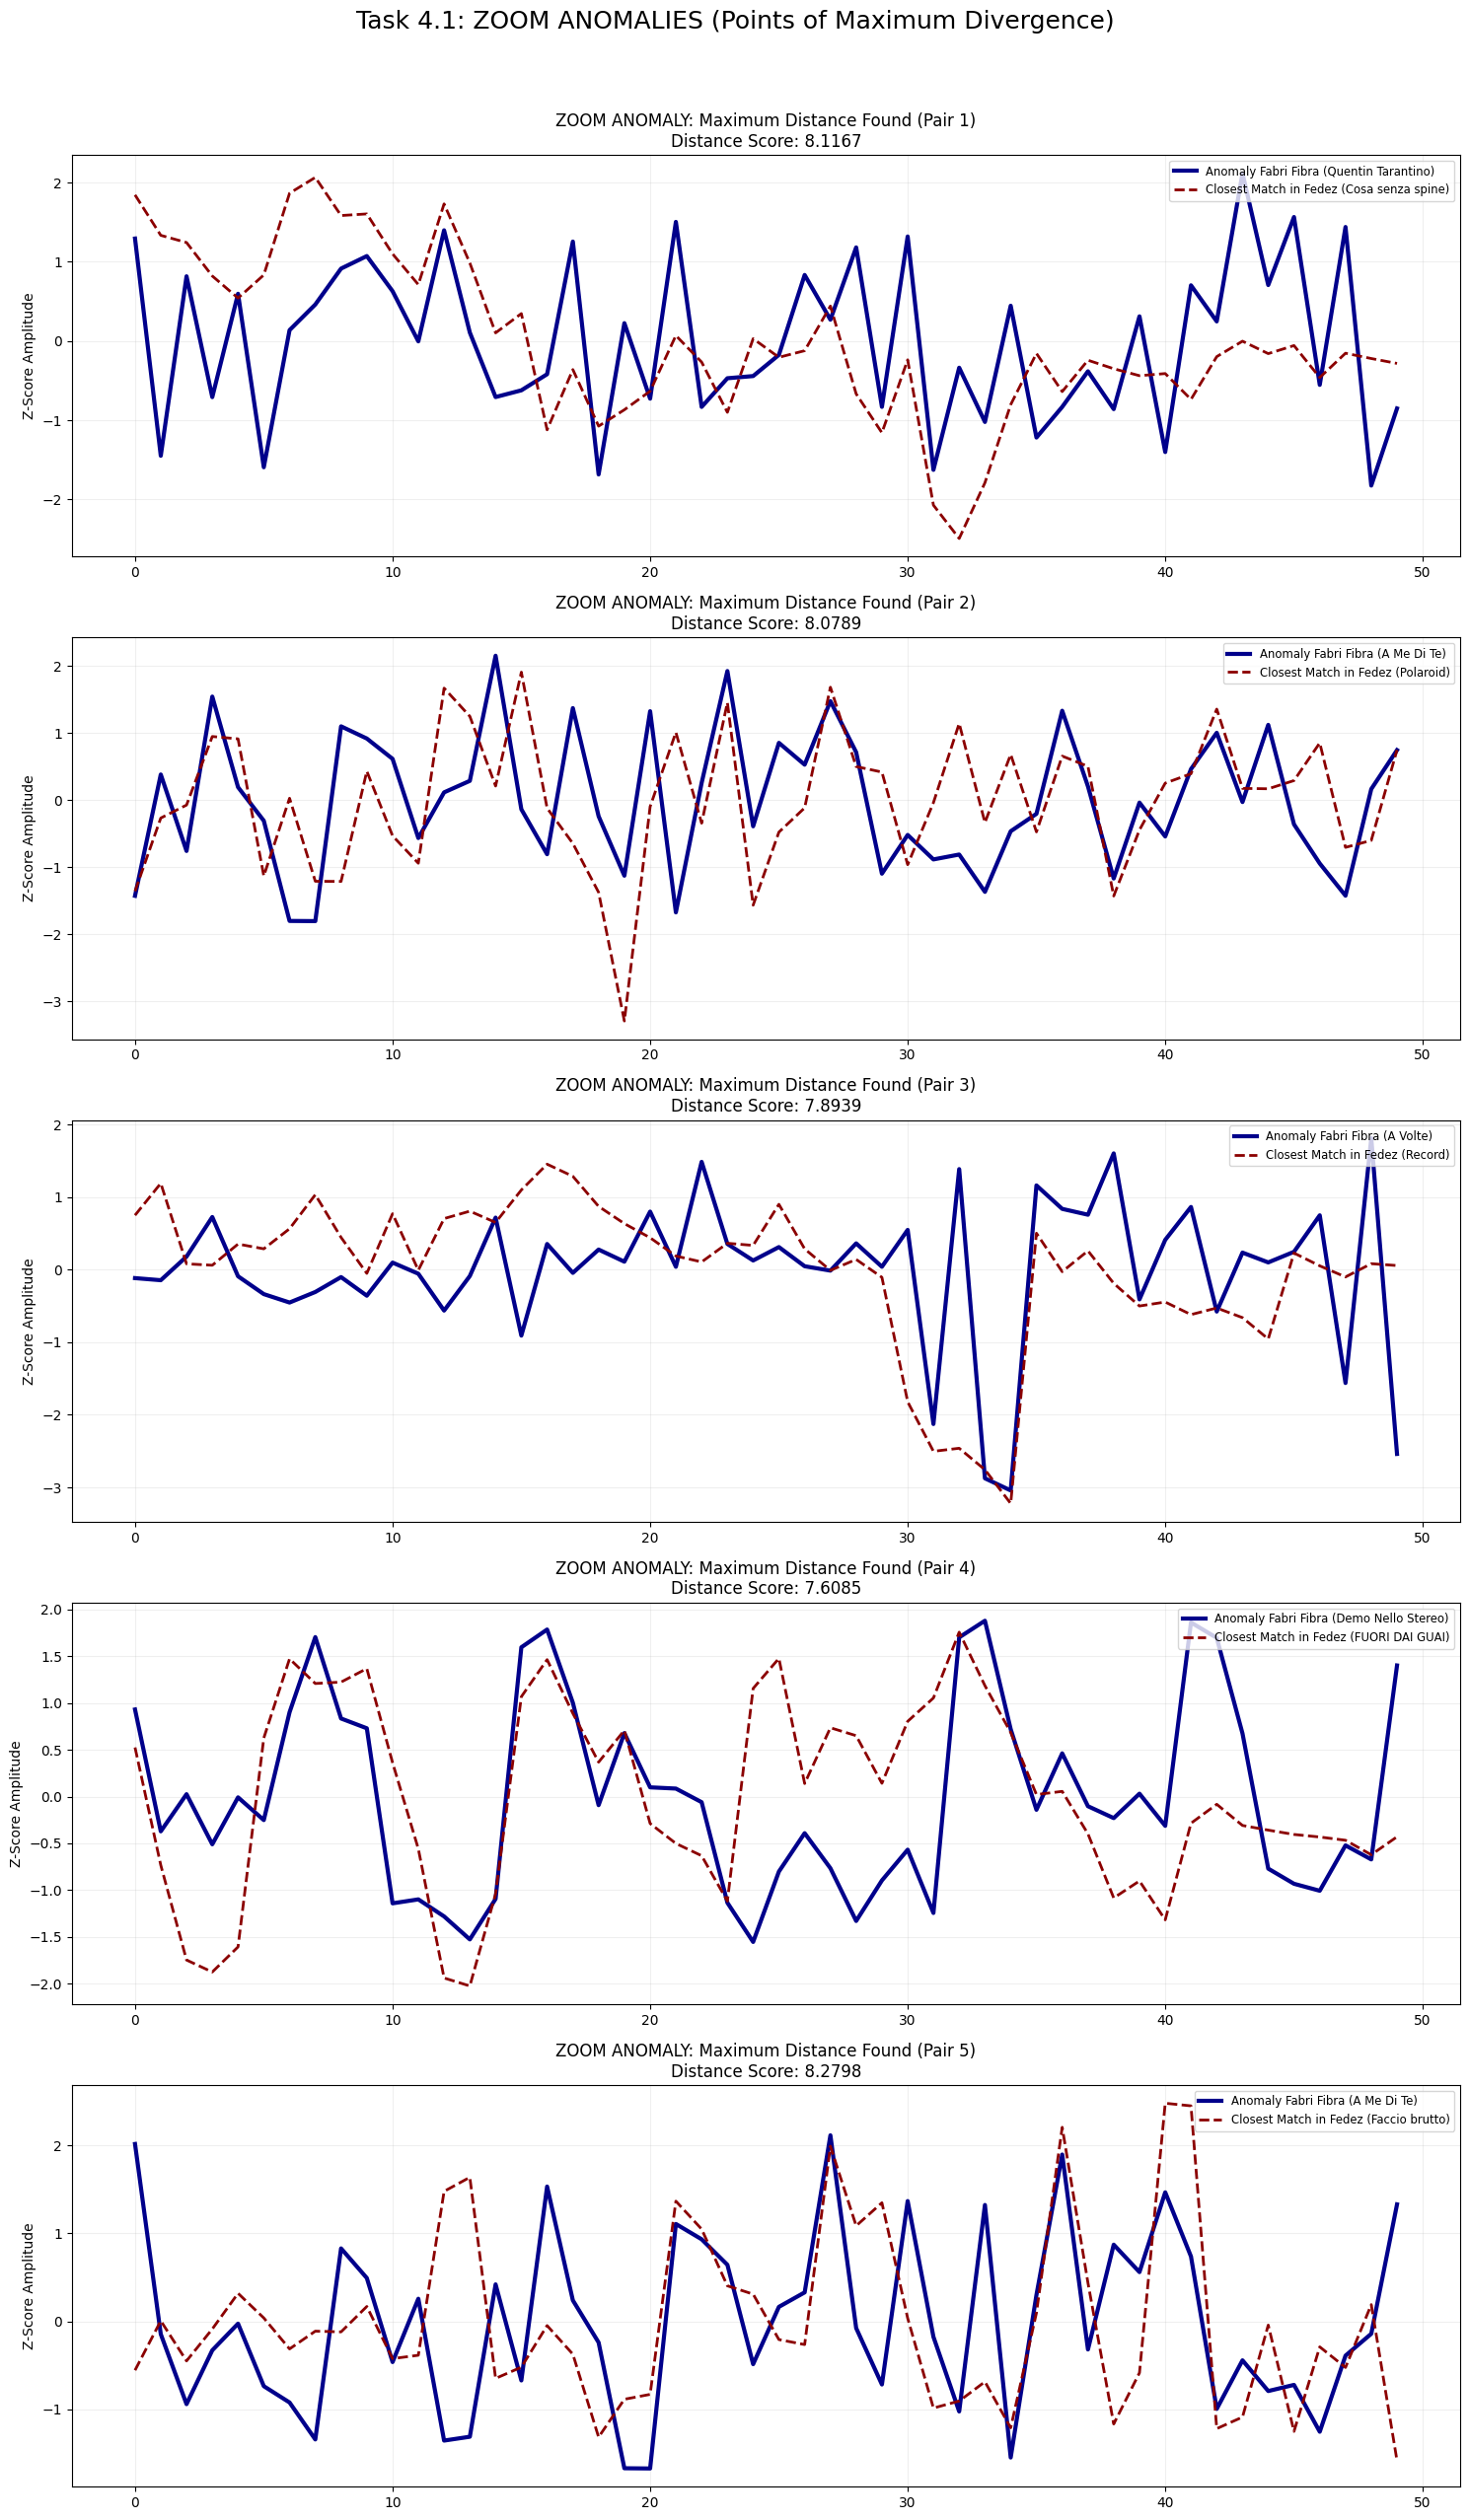

In [124]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

# Window of ~2 seconds
m = 50 

fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Task 4.1: ZOOM ANOMALIES (Points of Maximum Divergence)', fontsize=18, y=1.02)

# Using the top cross-artist matches in Cluster 1
for i, (index, row) in enumerate(df_meta_twins.head(5).iterrows()):
    # 1. Retrieve indices from synchronized metadata
    idx_a = df_analysis[df_analysis['track_id'] == row['id_1']].index[0]
    idx_b = df_analysis[df_analysis['track_id'] == row['id_2']].index[0]
    
    # 2. Extract 1D Time Series (Mean MFCC)
    s_a = X[idx_a, :, :].mean(axis=1).flatten().astype(float)
    s_b = X[idx_b, :, :].mean(axis=1).flatten().astype(float)
    
    # 3. STUMP AB-join: Calculate the distance of every subsequence in A relative to B
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b, ignore_trivial=False)
    
    # The CROSS-ARTIST ANOMALY is the point of MAXIMUM distance (argmax)
    # This is the section of Fedez that looks LEAST like any section of Fibra
    idx_a_discord = np.argmax(comp_mp[:, 0])
    
    # We still find the "least distant" point in B for visual contrast
    idx_b_nearest = comp_mp[idx_a_discord, 1]
    
    # 4. Segment Extraction
    seg_a = s_a[idx_a_discord : idx_a_discord + m]
    seg_b = s_b[idx_b_nearest : idx_b_nearest + m]
    
    # Z-Normalization for shape comparison
    seg_a_norm = (seg_a - np.mean(seg_a)) / np.std(seg_a)
    seg_b_norm = (seg_b - np.mean(seg_b)) / np.std(seg_b)
    
    # 5. Plotting
    ax = axes[i]
    ax.plot(seg_a_norm, label=f"Anomaly {row['artist_1']} ({row['song_1']})", lw=3, color='darkblue')
    ax.plot(seg_b_norm, label=f"Closest Match in {row['artist_2']} ({row['song_2']})", lw=2, color='darkred', linestyle='--')
    
    ax.set_title(f"ZOOM ANOMALY: Maximum Distance Found (Pair {i+1})\nDistance Score: {comp_mp[idx_a_discord, 0]:.4f}")
    ax.set_ylabel("Z-Score Amplitude")
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## General Motif

In [162]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 74 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       448 non-null    object 
 1   id_artist                      448 non-null    object 
 2   name_artist                    448 non-null    object 
 3   title                          448 non-null    object 
 4   featured_artists               448 non-null    object 
 5   language                       448 non-null    object 
 6   swear_IT                       448 non-null    int64  
 7   swear_EN                       448 non-null    int64  
 8   swear_IT_words                 448 non-null    object 
 9   swear_EN_words                 448 non-null    object 
 10  n_sentences                    448 non-null    float64
 11  n_tokens                       448 non-null    float64
 12  tokens_per_sent                448 non-null    flo

In [ ]:
from stumpy import motifs
import numpy as np

m = 86
n_motifs_per_song = 3
motif_book = []      # Inizializzazione come lista
motif_metadata = []

print("Estrazione motif con cutoff dinamico e min_neighbors=1...")

for i in range(X_scaled.shape[0]):
    # Estrazione dati canzone e metadati
    song_data = X_scaled[i].astype(np.float64)
    artist = df_analysis.iloc[i]['name_artist']
    song_title = df_analysis.iloc[i]['title']
    
    # 1. Calcolo Matrix Profile
    song_mean = song_data.mean(axis=1)
    mp = stumpy.stump(song_mean, m=m)
    
    # 2. Calcolo Cutoff Dinamico
    # Sostituisci il calcolo del cutoff con questo:
    min_dist = np.amin(mp[:, 0])

    # Se min_dist è 0, usiamo una piccola costante, altrimenti raddoppiamo il minimo
    calc_cutoff = max(min_dist * 2.0, 0.1)
        
    # 3. Ricerca Motif
    # min_neighbors=1: il pattern deve ripetersi almeno una volta per essere un motif
    match_distances, match_indices = motifs(
        song_mean, 
        mp[:, 0], 
        max_motifs=n_motifs_per_song, 
        cutoff=calc_cutoff, 
        min_neighbors=1 
    )
    
    # 4. Popolamento del Book
    for idx_list in match_indices:
        if len(idx_list) > 0:
            best_idx = idx_list[0]
            
            # Segmento con tutte le feature (es. 60)
            motif_segment = song_data[best_idx : best_idx + m, :]
            
            # Aggiungiamo alla lista (appiattito per il clustering)
            motif_book.append(motif_segment.flatten())
            motif_metadata.append({
                'artist': artist,
                'song': song_title,
                'index': best_idx
            })

# 5. Conversione finale in array NumPy
motif_book = np.array(motif_book)

print(f"✅ Book creato!")
print(f"   - Totale motif estratti: {len(motif_book)}")
print(f"   - Shape finale: {motif_book.shape}")

Estrazione motif con cutoff dinamico e min_neighbors=1...
✅ Book creato!
   - Totale motif estratti: 1326
   - Shape finale: (1326, 195)


## Euclidian based Clusters

In [164]:
# Creiamo una lista per i cluster dei motif
motif_clusters = []

for meta in motif_metadata:
    # Troviamo la riga della canzone nel dataframe usando titolo e artista
    # (Uso .iloc[0] assumendo che la combinazione titolo-artista sia univoca)
    song_row = df_analysis[(df_analysis['title'] == meta['song']) & 
                           (df_analysis['name_artist'] == meta['artist'])]
    
    if not song_row.empty:
        cluster_val = song_row['cluster_eu_unsup'].values[0]
        motif_clusters.append(cluster_val)
    else:
        motif_clusters.append(-1) # Valore di errore se non trova la canzone

motif_clusters = np.array(motif_clusters)

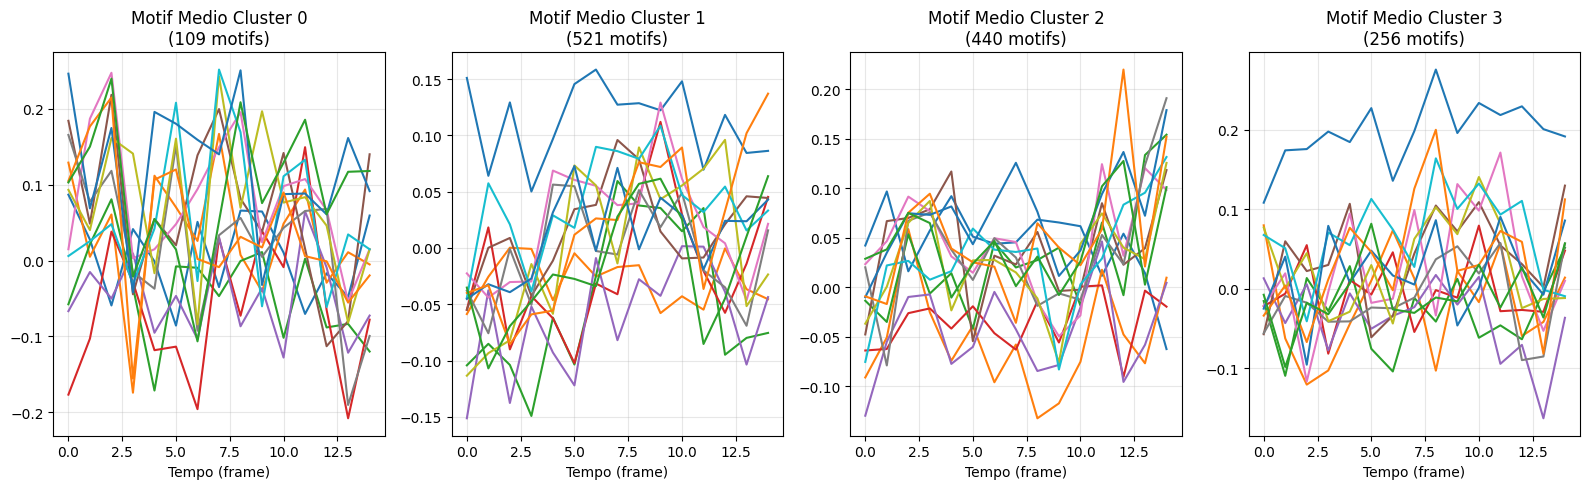

In [165]:
import matplotlib.pyplot as plt

# Numero di cluster unici (escludendo eventuali -1)
unique_clusters = sorted([c for c in np.unique(motif_clusters) if c != -1])

plt.figure(figsize=(16, 5))

for i, cl_id in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i + 1)
    
    # Prendiamo i motif appartenenti a questo cluster
    cl_motif_indices = np.where(motif_clusters == cl_id)[0]
    specific_motifs = motif_book[cl_motif_indices]
    
    if len(specific_motifs) > 0:
        # Calcoliamo il motif medio del cluster
        # Torniamo alla forma (m, features) -> (15, 13)
        mean_motif = specific_motifs.mean(axis=0).reshape(15, -1)
        
        plt.plot(mean_motif)
        plt.title(f"Motif Medio Cluster {cl_id}\n({len(specific_motifs)} motifs)")
        plt.xlabel("Tempo (frame)")
        plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

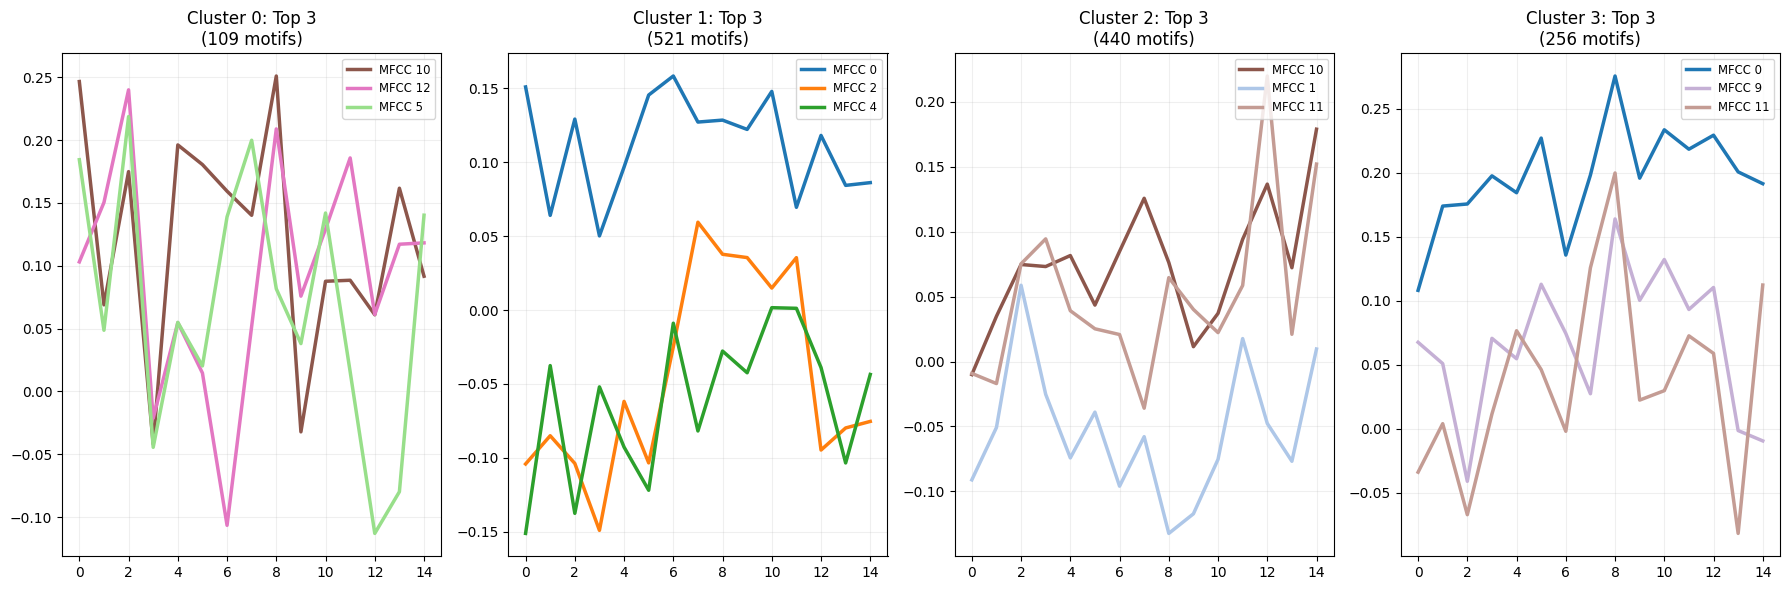

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definiamo una palette di colori fissa per le 13 feature
# 'tab20' è ottima perché ha 20 colori distinti, perfetti per i tuoi 13 MFCC
cmap = plt.get_cmap('tab20')

n_feat_to_show = 3 
m_frames = 86
n_features = 13

plt.figure(figsize=(18, 6))

for i, cl_id in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i + 1)
    
    cl_indices = np.where(motif_clusters == cl_id)[0]
    specific_motifs = motif_book[cl_indices].reshape(-1, m_frames, n_features)
    
    if len(specific_motifs) > 0:
        mean_motif = specific_motifs.mean(axis=0)
        importance = np.abs(mean_motif).mean(axis=0)
        top_indices = np.argsort(importance)[-n_feat_to_show:][::-1]
        
        for feat_idx in top_indices:
            # 2. Assegniamo il colore in base all'indice della feature, non all'ordine di plot
            plt.plot(mean_motif[:, feat_idx], 
                     label=f"MFCC {feat_idx}", 
                     color=cmap(feat_idx),  # <--- COLORE FISSO QUI
                     linewidth=2.5)
        
        plt.title(f"Cluster {cl_id}: Top {n_feat_to_show}\n({len(cl_indices)} motifs)")
        plt.legend(fontsize='small', loc='upper right')
        plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Spectrogram

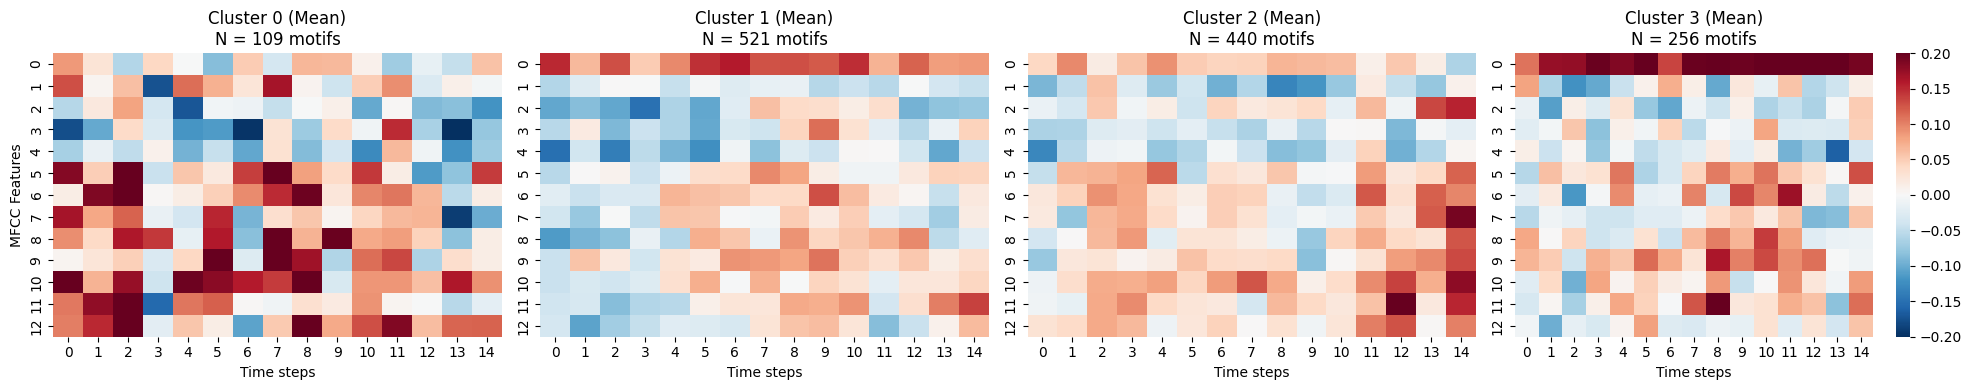

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Parametri presi dal tuo setup
m_frames = 86
n_features = 13
unique_clusters = np.unique(motif_clusters)
unique_clusters = unique_clusters[unique_clusters != -1] # Escludiamo eventuali errori (-1)

# Calcolo del numero di colonne per il plot
n_clusters = len(unique_clusters)
plt.figure(figsize=(5 * n_clusters, 4)) # Si adatta dinamicamente al numero di cluster

for i, cl_id in enumerate(unique_clusters):
    ax = plt.subplot(1, n_clusters, i + 1)
    
    # 1. Estraiamo i motif del cluster e calcoliamo la media
    cl_indices = np.where(motif_clusters == cl_id)[0]
    # Reshape: (numero_motif, tempo, feature)
    specific_motifs = motif_book[cl_indices].reshape(-1, m_frames, n_features)
    
    if len(specific_motifs) > 0:
        # Calcoliamo il motif "prototipo" del cluster:
        # $$\bar{M} = \frac{1}{N} \sum_{i=1}^{N} Motif_i$$
        mean_motif = specific_motifs.mean(axis=0)
        
        # 2. Plotting come Heatmap
        # Trasponiamo per avere le Feature (13) sulle Y e il Tempo (15) sulle X
        sns.heatmap(mean_motif.T, 
                    ax=ax, 
                    cmap='RdBu_r', 
                    cbar=(i == n_clusters - 1), # Mostra la barra solo nell'ultimo plot
                    vmin=-0.2, vmax=0.2) # Opzionale: fissa il range se i dati sono scalati
        
        ax.set_title(f"Cluster {cl_id} (Mean)\nN = {len(cl_indices)} motifs")
        ax.set_xlabel("Time steps")
        if i == 0:
            ax.set_ylabel("MFCC Features")
        else:
            ax.set_ylabel("")

plt.tight_layout()
plt.show()

Clusters dimension 37 177 148  86

## General Anomalies

In [ ]:
import numpy as np
import stumpy

m = 86
n_anomalies_per_song = 3
anomaly_book = []
anomaly_metadata = []

print(f"Estrazione di {n_anomalies_per_song} anomalie per brano (manual masking)...")

for i in range(X_scaled.shape[0]):
    song_data = X_scaled[i].astype(np.float64)
    artist = df_analysis.iloc[i]['name_artist']
    song_title = df_analysis.iloc[i]['title']
    
    # 1. Calcolo Matrix Profile
    song_mean = song_data.mean(axis=1)
    mp = stumpy.stump(song_mean, m=m)
    
    # Copiamo le distanze per poterle modificare (mascherare)
    distances = mp[:, 0].copy()
    
    for _ in range(n_anomalies_per_song):
        # 2. Trova l'indice del valore massimo (l'anomalia)
        d_idx = np.argmax(distances)
        d_dist = distances[d_idx]
        
        # 3. Salvataggio nel book
        anomaly_segment = song_data[d_idx : d_idx + m, :]
        anomaly_book.append(anomaly_segment.flatten())
        anomaly_metadata.append({
            'artist': artist,
            'song': song_title,
            'index': d_idx,
            'distance': d_dist
        })
        
        # 4. MASCHERAMENTO: azzeriamo l'area intorno all'anomalia trovata 
        # per non riprendere lo stesso punto (raggio di esclusione = m)
        start = max(0, d_idx - m)
        end = min(len(distances), d_idx + m)
        distances[start:end] = -1.0 # Usiamo -1 perché le distanze reali sono >= 0

anomaly_book = np.array(anomaly_book)
print(f"✅ Fatto! Totale anomalie estratte: {len(anomaly_book)}")

Estrazione di 3 anomalie per brano (manual masking)...
✅ Fatto! Totale anomalie estratte: 1344


In [201]:
# Creiamo la lista dei cluster per le anomalie
anomaly_clusters = []

for meta in anomaly_metadata:
    # Troviamo il cluster della canzone corrispondente nel dataframe
    song_row = df_analysis[(df_analysis['title'] == meta['song']) & 
                           (df_analysis['name_artist'] == meta['artist'])]
    
    if not song_row.empty:
        cluster_val = song_row['cluster_eu_unsup'].values[0]
        anomaly_clusters.append(cluster_val)
    else:
        anomaly_clusters.append(-1)

anomaly_clusters = np.array(anomaly_clusters)

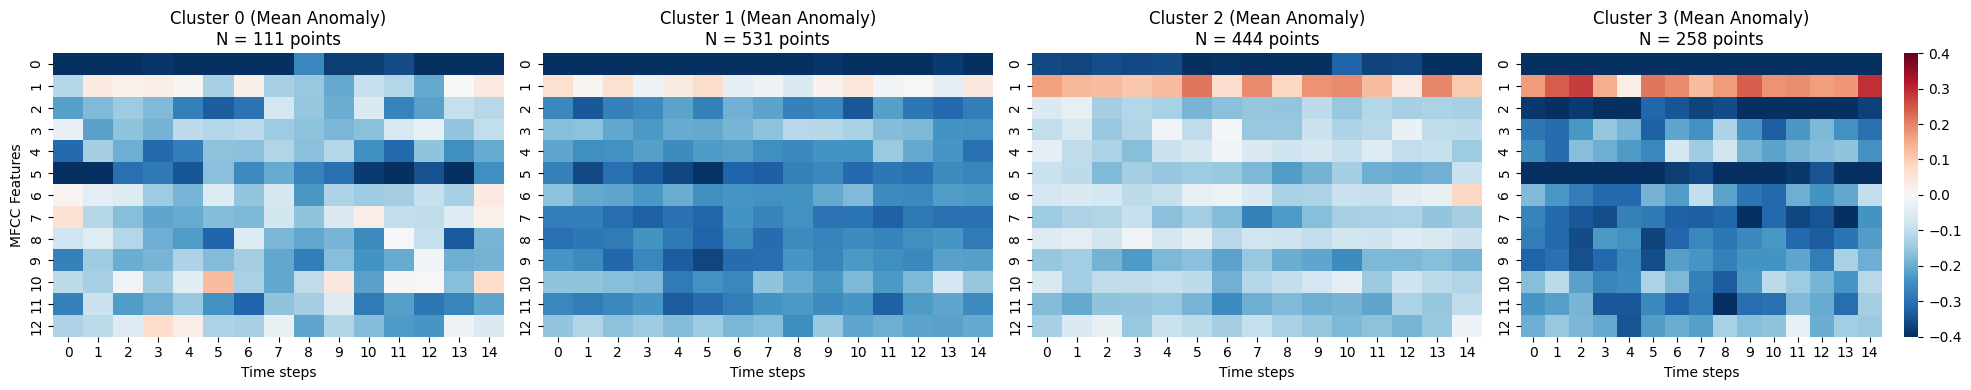

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Parametri del segnale
m_frames = 86
n_features = 13
unique_clusters = np.unique(anomaly_clusters)
unique_clusters = unique_clusters[unique_clusters != -1] # Escludiamo errori

n_clusters = len(unique_clusters)
plt.figure(figsize=(5 * n_clusters, 4))

for i, cl_id in enumerate(unique_clusters):
    ax = plt.subplot(1, n_clusters, i + 1)
    
    # 1. Filtriamo le anomalie appartenenti a questo cluster di canzoni
    cl_indices = np.where(anomaly_clusters == cl_id)[0]
    specific_anomalies = anomaly_book[cl_indices].reshape(-1, m_frames, n_features)
    
    if len(specific_anomalies) > 0:
        # 2. Calcolo dell'anomalia media del cluster
        mean_anomaly = specific_anomalies.mean(axis=0)
        
        # 3. Plotting Heatmap
        sns.heatmap(mean_anomaly.T, 
                    ax=ax, 
                    cmap='RdBu_r', # 'rocket' è ottimo per le anomalie (toni caldi/scuri)
                    cbar=(i == n_clusters - 1),
                    vmin=-0.4, vmax=0.4) # Regola in base al tuo scaling
        
        ax.set_title(f"Cluster {cl_id} (Mean Anomaly)\nN = {len(cl_indices)} points")
        ax.set_xlabel("Time steps")
        if i == 0:
            ax.set_ylabel("MFCC Features")
        else:
            ax.set_ylabel("")

plt.tight_layout()
plt.show()

## ---------------------------------- corretto fino a qui-------------------------------------------

# Shapelet Analysis

## LORENZO METODO 1

In [9]:
from tslearn.shapelets import grabocka_params_to_shapelet_size_dict

from tslearn.preprocessing import TimeSeriesScalerMinMax

from tslearn.utils import to_time_series_dataset

In [12]:
# 1. Define your mapping (Who is 0 and who is 1?)
# Make sure the strings match exactly what is in your dataframe (check for lowercase)
artist_mapping = {
    'fedez': 0,
    'fabri fibra': 1
}

# 2. Create the labels
# We iterate through the dataframe to ensure the order matches X_final exactly
y_true = []

print("🏷️ Generating labels from 'name_artist'...")

for artist in df_processed['name_artist']:
    # Convert to lowercase to be safe
    clean_name = str(artist).lower().strip()
    
    if clean_name in artist_mapping:
        y_true.append(artist_mapping[clean_name])
    else:
        # Fallback if there's a typo or different name (e.g. "Fedez feat...")
        # You might want to print these to check
        if 'fedez' in clean_name:
            y_true.append(0)
        elif 'fibra' in clean_name:
            y_true.append(1)
        else:
            print(f"⚠️ Warning: Unknown artist '{artist}' found. Assigning -1.")
            y_true.append(-1)

# 3. Convert to Numpy Array
y_true = np.array(y_true)

# 4. Verification
print(f"✅ y_true created! Shape: {y_true.shape}")
print(f"   Count for Fedez (0): {np.sum(y_true == 0)}")
print(f"   Count for Fibra (1): {np.sum(y_true == 1)}")

# Check if X_final and y_true match in length
if 'X_final' in locals() and len(X) != len(y_true):
    print(f"❌ ERROR: Mismatch! X has {len(X)} items, but y_true has {len(y_true)}.")
else:
    print("✅ Lengths match perfectly with X.")

X_shape = to_time_series_dataset(X)
y_shape = y_true # 0 per Fedez, 1 per Fibra


🏷️ Generating labels from 'name_artist'...
✅ y_true created! Shape: (448,)
   Count for Fedez (0): 173
   Count for Fibra (1): 275
✅ Lengths match perfectly with X.


In [13]:
import numpy as np
from tslearn.shapelets import LearningShapelets, grabocka_params_to_shapelet_size_dict
from tslearn.preprocessing import TimeSeriesScalerMinMax

# 1. Verifica e Scaling
# X_final shape: (448, 2584, 13)
# Il modello LearningShapelets beneficia enormemente dallo scaling MinMax (0, 1)
X_scaled_ls = TimeSeriesScalerMinMax().fit_transform(X)

# 2. Estrazione dimensioni corrette
n_ts, ts_sz, n_features = X_scaled_ls.shape
n_classes = len(np.unique(y_true)) # Assicurati che y sia definito (es. i tuoi generi)

# 3. Calcolo parametri di Grabocka
# Nota: l=0.1 significa che la shapelet sarà lunga il 10% di 2584 (~258 punti)
# r=1 significa che usiamo una sola scala di lunghezza. 
shapelet_sizes = grabocka_params_to_shapelet_size_dict(
    n_ts=n_ts,
    ts_sz=ts_sz,
    n_classes=n_classes,
    l=0.1,
    r=1
)

print(f"Dimensioni: {n_ts} tracce, {ts_sz} sample, {n_features} feature")
print(f"Classi rilevate: {n_classes}")
print(f"Shapelet pianificate: {shapelet_sizes}")

# 4. Inizializzazione del modello adattato per dati multivariati
# Il parametro 'n_shapelets_per_size' accetta il dizionario appena creato
shp_clf = LearningShapelets(
    n_shapelets_per_size=shapelet_sizes,
    optimizer="adam",
    batch_size=16,
    weight_regularizer=0.01,
    max_iter=50,        # Aumenta a 200+ per risultati reali
    random_state=42,
    verbose=1
)

# 5. Training
# shp_clf.fit(X_scaled_ls, y)

Dimensioni: 448 tracce, 2584 sample, 13 feature
Classi rilevate: 2
Shapelet pianificate: {258: 6}


In [15]:
# 5. Training
shp_clf.fit(X_scaled_ls, y_true)

/home/filippo/prova/venv/lib/python3.12/site-packages/tslearn/shapelets/shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
/home/filippo/prova/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 474s 17s/step - binary_accuracy: 0.6049 - binary_crossentropy: 0.6678 - loss: 0.6933
Epoch 2/50
26/28 ━━━━━━━━━━━━━━━━━━━━ 31s 16s/step - binary_accuracy: 0.5844 - binary_crossentropy: 0.6705 - loss: 0.6958

KeyboardInterrupt: 

In [ ]:
from tslearn.shapelets import LearningShapelets
from tslearn.utils import to_time_series_dataset

# 1. Prepariamo il dataset (tslearn vuole un formato specifico)
# Usiamo X_final che contiene le tue serie temporali 500x13
X_shape = to_time_series_dataset(X_final)
y_shape = y_true # 0 per Fedez, 1 per Fibra

# 2. Configuriamo il modello
# Cerchiamo 1 shapelet di lunghezza 50 (circa 2-3 secondi di audio)
n_shapelets = 1
shapelet_length = 50
lpdtw = LearningShapelets(n_shapelets_per_size={shapelet_length: n_shapelets},
                          max_iter=100,
                          verbose=0,
                          random_state=42)

# 3. Addestramento (il modello "impara" la forma distintiva)
print("Estrazione della Shapelet in corso... potrebbe richiedere un momento.")
lpdtw.fit(X_shape, y_shape)

# 4. Recuperiamo la Shapelet imparata
# È una forma che rappresenta il "confine" tra i due artisti
shapelet_distintiva = lpdtw.shapelets_[0].flatten()

Estrazione della Shapelet in corso... potrebbe richiedere un momento.


d:\Anaconda\envs\mining_env\Lib\site-packages\tslearn\shapelets\shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


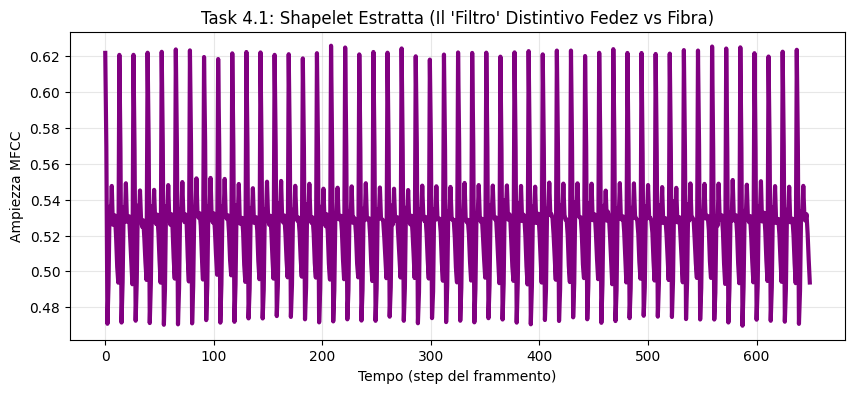

In [53]:
plt.figure(figsize=(10, 4))
plt.plot(shapelet_distintiva, color='purple', lw=3)
plt.title("Task 4.1: Shapelet Estratta (Il 'Filtro' Distintivo Fedez vs Fibra)")
plt.xlabel("Tempo (step del frammento)")
plt.ylabel("Ampiezza MFCC")
plt.grid(True, alpha=0.3)
plt.show()

## Multishapelet extraction

In [54]:
from tslearn.shapelets import LearningShapelets

# Definiamo diverse scale temporali: 25 step (~1s) e 100 step (~4s)
shapelet_sizes = {25: 2, 100: 1} 

ls = LearningShapelets(n_shapelets_per_size=shapelet_sizes,
                       max_iter=100,
                       random_state=42,
                       verbose=0)

ls.fit(X_shape, y_shape)

# Ora abbiamo 3 shapelets totali (2 corte, 1 lunga)
shapelets = ls.shapelets_

d:\Anaconda\envs\mining_env\Lib\site-packages\tslearn\shapelets\shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs

## Probability distribution analysis

### La vera analisi profonda consiste nel vedere quanto una canzone è "vicina" alla Shapelet di Fedez o a quella di Fibra. Questo trasforma una forma d'onda in un punteggio di probabilità

d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


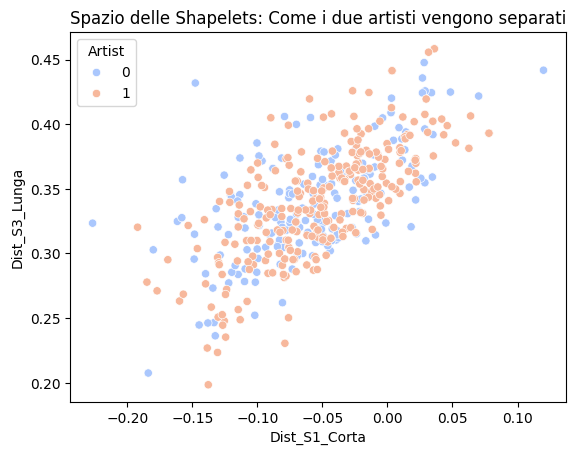

In [55]:
# Trasformiamo le serie temporali nello spazio delle distanze dalle shapelet
X_distances = ls.transform(X_shape)

# Creiamo un DataFrame per l'analisi
df_dist = pd.DataFrame(X_distances, columns=['Dist_S1_Corta', 'Dist_S2_Corta', 'Dist_S3_Lunga'])
df_dist['Artist'] = y_true # 0: Fedez, 1: Fibra

# Visualizziamo come le Shapelet separano i due artisti
sns.scatterplot(data=df_dist, x='Dist_S1_Corta', y='Dist_S3_Lunga', hue='Artist', palette='coolwarm')
plt.title("Spazio delle Shapelets: Come i due artisti vengono separati")
plt.show()

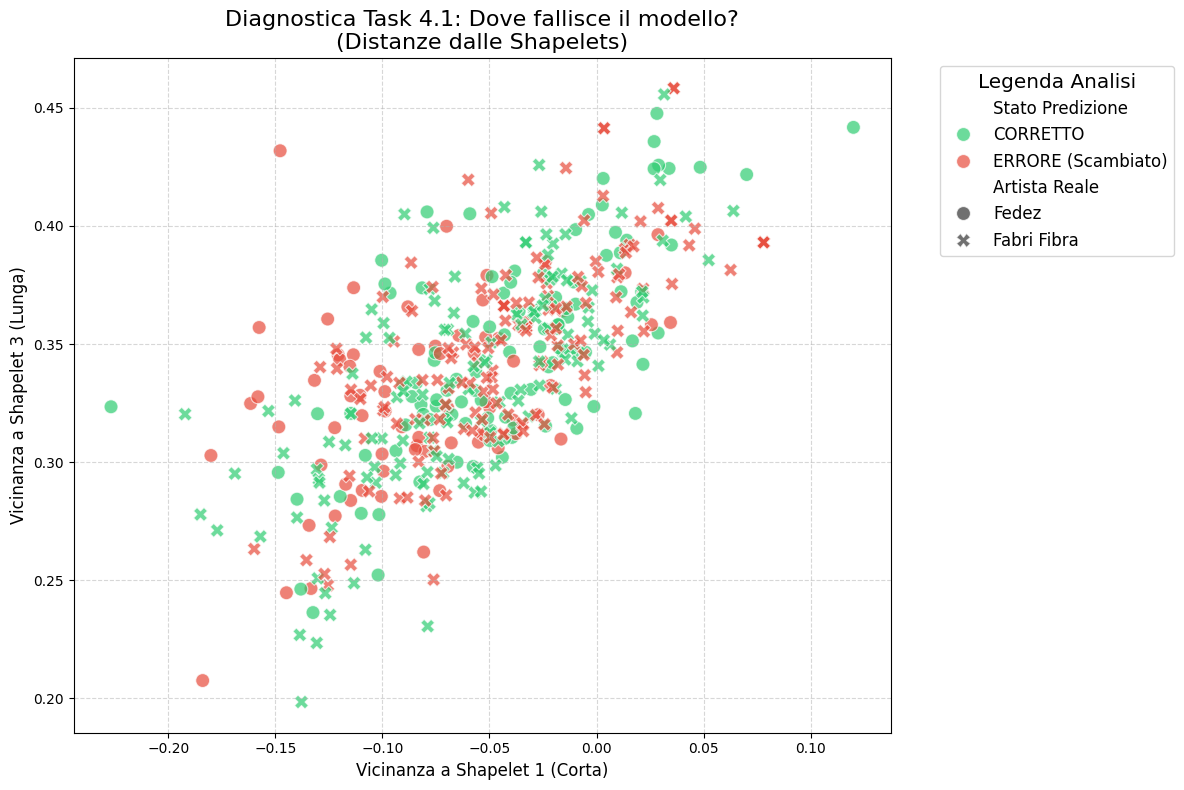

In [88]:
# Creiamo una colonna descrittiva per la legenda
df_dist['Stato Predizione'] = df_dist['Is_Error'].map({True: 'ERRORE (Scambiato)', False: 'CORRETTO'})
df_dist['Artista Reale'] = df_dist['Artist'].map({0: 'Fedez', 1: 'Fabri Fibra'})

plt.figure(figsize=(12, 8))

# Usiamo una palette molto contrastata: Rosso per l'errore, Verde per il corretto
palette_colori = {'ERRORE (Scambiato)': '#e74c3c', 'CORRETTO': '#2ecc71'}

sns.scatterplot(
    data=df_dist, 
    x='Dist_S1_Corta', 
    y='Dist_S3_Lunga', 
    hue='Stato Predizione',   # Il colore dice se il modello ha sbagliato
    style='Artista Reale',    # La forma (cerchio/croce) dice chi è l'autore
    palette=palette_colori,
    s=100,                    # Punti più grandi per vederli meglio
    alpha=0.7,
    edgecolor='w'
)

# Spostiamo la legenda fuori dal grafico per non coprire i punti
plt.legend(title='Legenda Analisi', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='large', title_fontsize='x-large')

plt.title("Diagnostica Task 4.1: Dove fallisce il modello?\n(Distanze dalle Shapelets)", fontsize=16)
plt.xlabel("Vicinanza a Shapelet 1 (Corta)", fontsize=12)
plt.ylabel("Vicinanza a Shapelet 3 (Lunga)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analisi "Localizzativa": Dove appare la Shapelet?
### Questa è la parte più descrittiva: prendiamo una canzone dove il modello ha sbagliato e cerchiamo se la "Shapelet di Fibra" appare comunque, traendo in inganno il sistema.

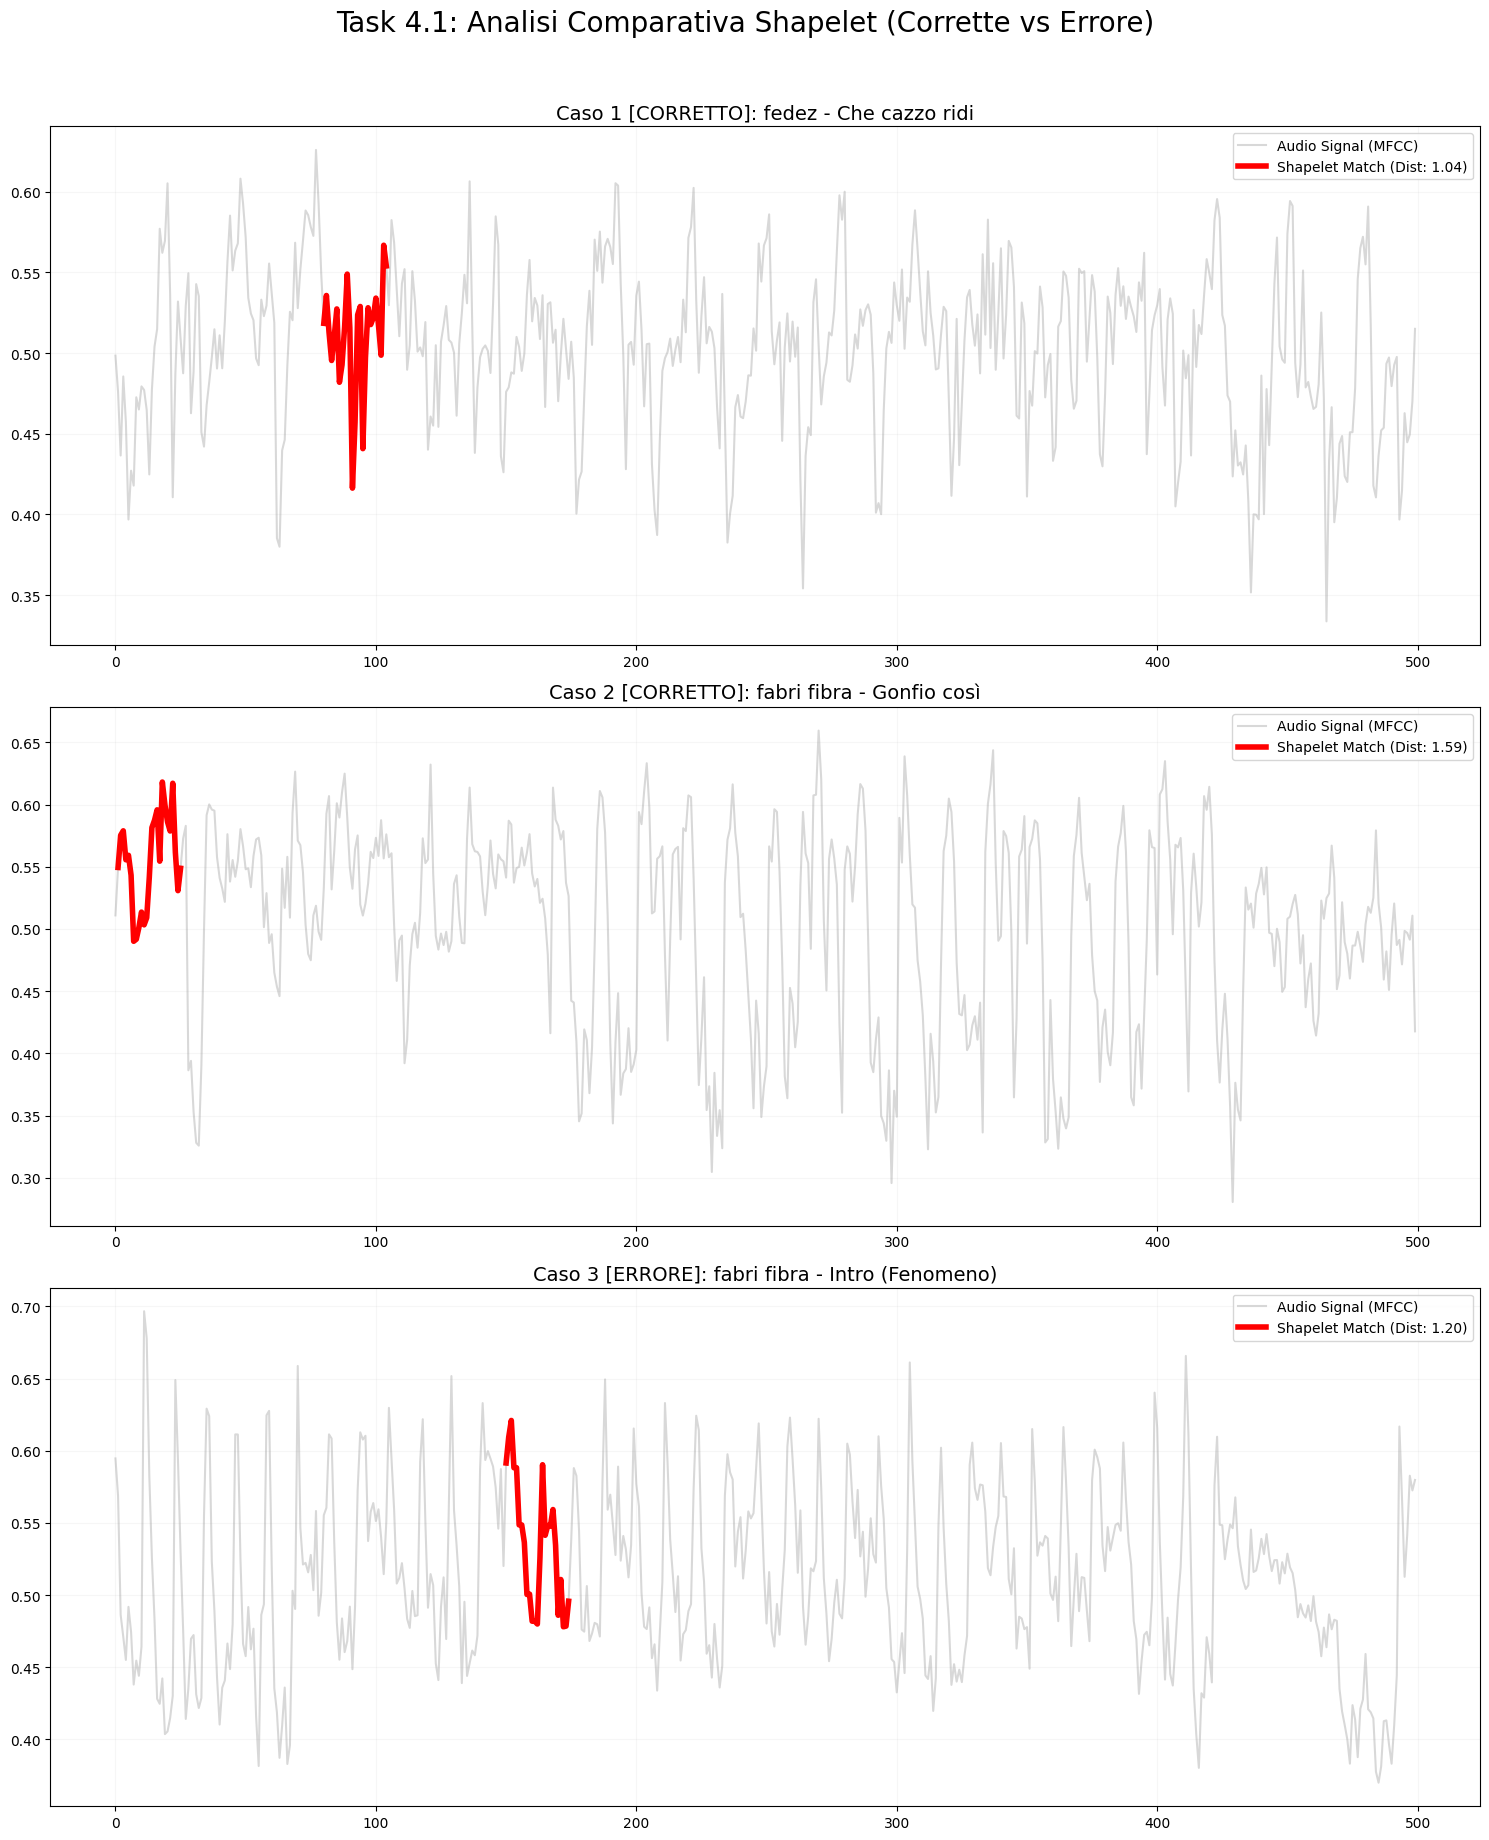

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def get_best_shapelet_match(idx_song, shapelet):
    ts = X_final[idx_song, :, :].mean(axis=1).flatten().astype(float)
    s = shapelet.flatten()
    # Calcolo distanza sliding window
    distances = [np.linalg.norm(ts[i:i+len(s)] - s) for i in range(len(ts)-len(s))]
    return ts, np.argmin(distances), np.min(distances)

# 1. Identifichiamo i tre casi (cambia gli indici se necessario)
# Caso A: Un Fedez predetto correttamente (non deve essere negli error_tr_codes)
id_fedez_ok = df[(df['name_artist'] == 'fedez') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso B: Un Fibra predetto correttamente
id_fibra_ok = df[(df['name_artist'] == 'fabri fibra') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso C: L'errore puro che abbiamo isolato prima
id_errore = errori_puri_ids[0]

casi = [id_fedez_ok, id_fibra_ok, id_errore]
shapelet_da_testare = shapelets[0] # La prima shapelet imparata

fig, axes = plt.subplots(3, 1, figsize=(15, 18))
fig.suptitle('Task 4.1: Analisi Comparativa Shapelet (Corrette vs Errore)', fontsize=20, y=1.02)

for i, track_id in enumerate(casi):
    idx = get_row_index(track_id)
    info = df.iloc[idx]
    ts, best_idx, dist = get_best_shapelet_match(idx, shapelet_da_testare)
    
    ax = axes[i]
    ax.plot(ts, color='gray', alpha=0.3, label='Audio Signal (MFCC)')
    # Evidenzio il match della shapelet
    ax.plot(range(best_idx, best_idx+len(shapelet_da_testare)), 
            ts[best_idx:best_idx+len(shapelet_da_testare)], 
            color='red', lw=4, label=f'Shapelet Match (Dist: {dist:.2f})')
    
    # Titolo dinamico
    tipo = "CORRETTO" if track_id not in error_tr_codes else "ERRORE"
    ax.set_title(f"Caso {i+1} [{tipo}]: {info['name_artist']} - {info['title']}", fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

In [61]:
# Vediamo quanti errori ha fatto il modello per ogni artista
error_df = df[df['track_id'].isin(error_tr_codes)]
print("Distribuzione degli errori per artista reale:")
print(error_df['name_artist'].value_counts())

Distribuzione degli errori per artista reale:
name_artist
fabri fibra    142
fedez           69
Name: count, dtype: int64


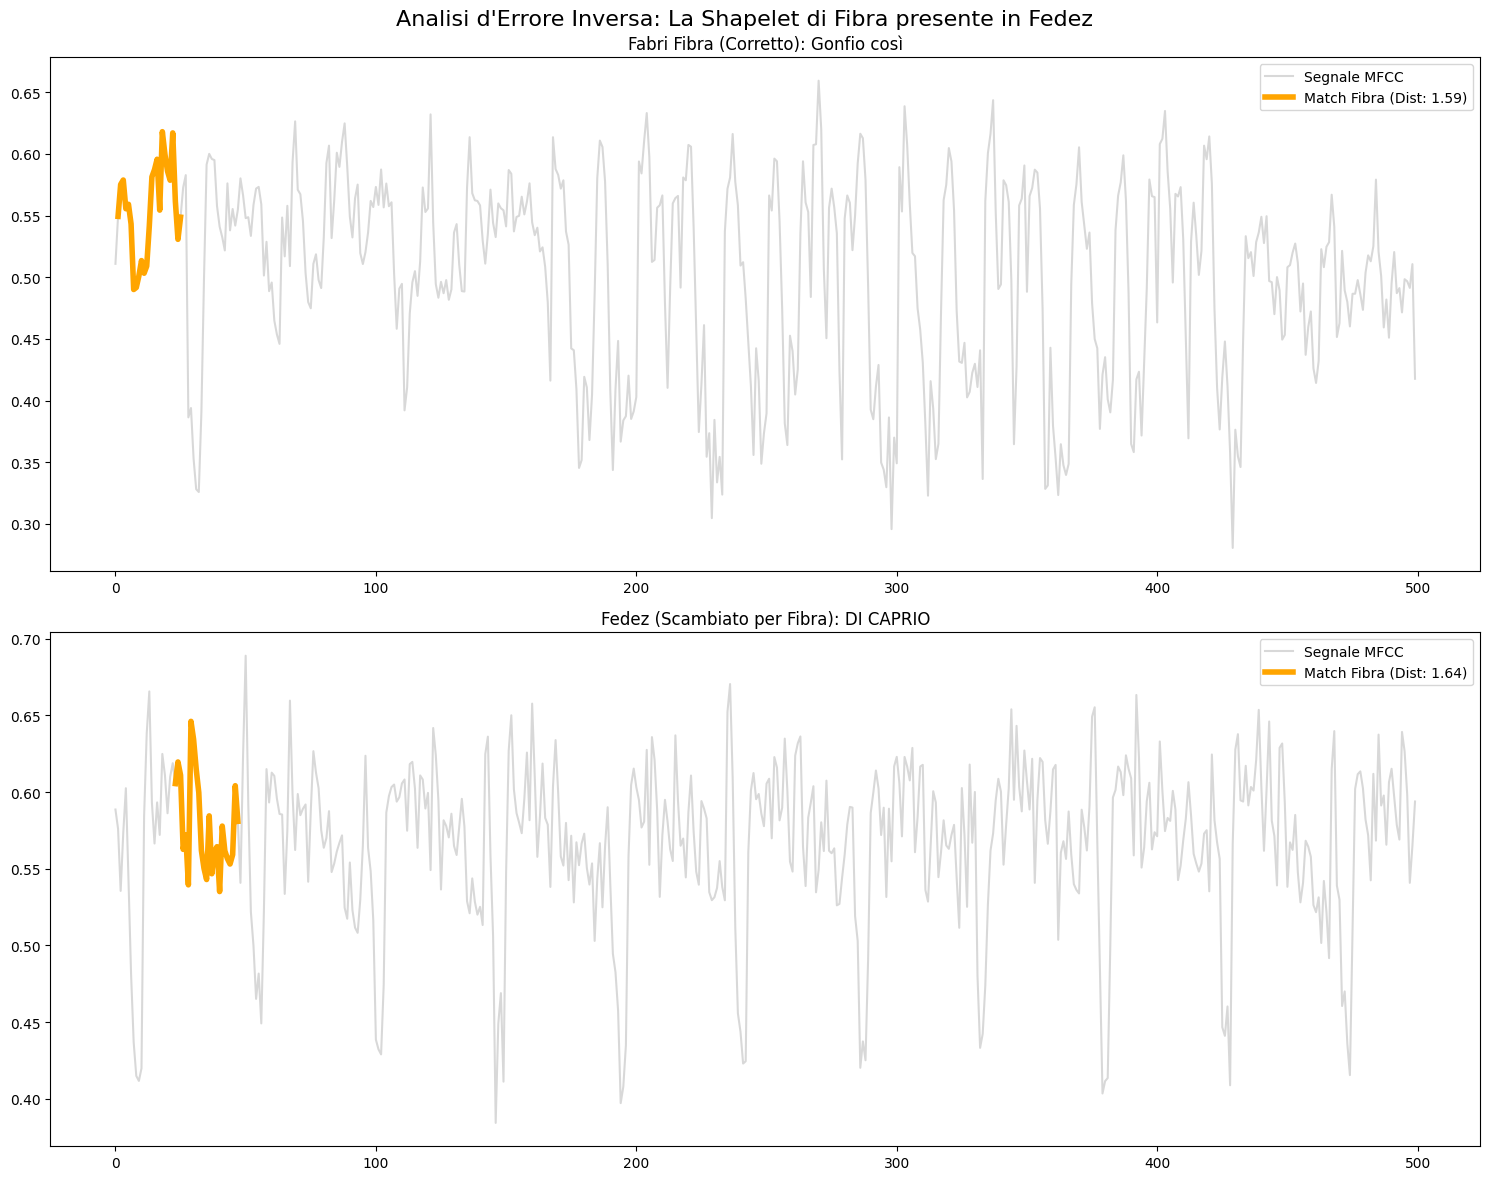

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Troviamo una Shapelet specifica per Fabri Fibra (Classe 1)
# Calcoliamo la distanza media di ogni shapelet dai brani di Fibra (y=1)
X_distances = ls.transform(X_shape)
mean_dist_fibra = X_distances[y_true == 1].mean(axis=0)
best_shapelet_idx_fibra = np.argmin(mean_dist_fibra)
shapelet_fibra = ls.shapelets_[best_shapelet_idx_fibra]

# 2. Selezioniamo i due casi per il confronto inverso
# Caso A: Fabri Fibra riconosciuto correttamente
id_fibra_ok = df[(df['name_artist'] == 'fabri fibra') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso B: Fedez riconosciuto ERRONEAMENTE come Fibra
# Cerchiamo un brano dove l'artista reale è Fedez ma il modello ha fallito assegnandolo a Fibra
id_fedez_scambiato = df[(df['name_artist'] == 'fedez') & (df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

casi_confronto_inv = [id_fibra_ok, id_fedez_scambiato]
titles_inv = ["Fabri Fibra (Corretto)", "Fedez (Scambiato per Fibra)"]

fig, axes = plt.subplots(2, 1, figsize=(15, 12))
fig.suptitle('Analisi d\'Errore Inversa: La Shapelet di Fibra presente in Fedez', fontsize=16)

for i, track_id in enumerate(casi_confronto_inv):
    idx = get_row_index(track_id)
    ts, best_idx, dist = get_best_shapelet_match(idx, shapelet_fibra)
    
    # ESTRAIAMO IL SEGMENTO PER NORMALIZZARLO (Z-Score)
    segmento = ts[best_idx:best_idx+len(shapelet_fibra)]
    # (segmento - media) / deviazione standard per vedere la FORMA pura
    seg_norm = (segmento - np.mean(segmento)) / (np.std(segmento) + 1e-8)
    sha_norm = (shapelet_fibra.flatten() - np.mean(shapelet_fibra)) / (np.std(shapelet_fibra) + 1e-8)

    ax = axes[i]
    # Plottiamo il segnale originale in sottofondo
    ax.plot(ts, color='gray', alpha=0.3, label='Segnale MFCC')
    
    # Evidenziamo il match
    ax.plot(range(best_idx, best_idx+len(shapelet_fibra)), 
            ts[best_idx:best_idx+len(shapelet_fibra)], 
            color='orange', lw=4, label=f'Match Fibra (Dist: {dist:.2f})')
    
    ax.set_title(f"{titles_inv[i]}: {df.iloc[idx]['title']}")
    ax.legend()
plt.tight_layout()
plt.show()

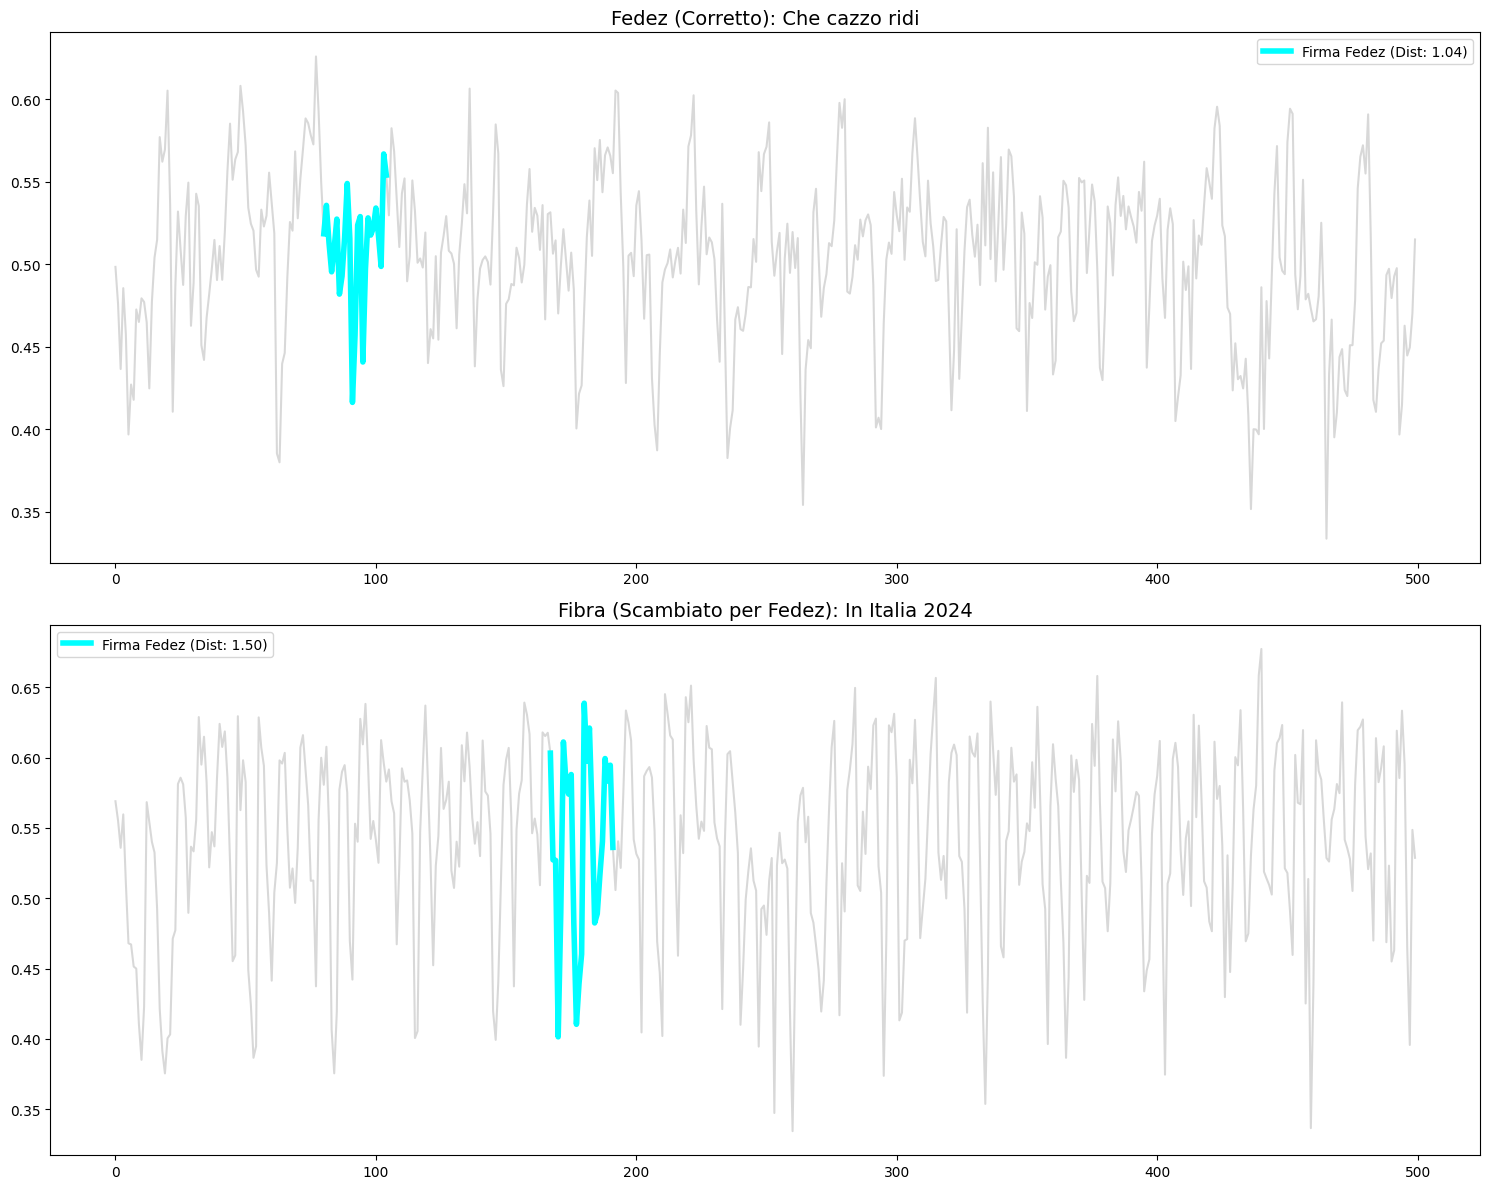

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# 1. IDENTIFICAZIONE COMPLETA ERRORI (Fibra -> Fedez E Fedez -> Fibra)
idx_fibra_as_fedez = np.where((y_true == 1) & (y_pred == 0))[0]
idx_fedez_as_fibra = np.where((y_true == 0) & (y_pred == 1))[0]

error_tr_codes = [names[i].split(' - ')[-1].replace('.mp3', '') for i in np.concatenate([idx_fibra_as_fedez, idx_fedez_as_fibra])]

# 2. SELEZIONE SHAPELET DISCRIMINANTE PER FEDEZ
# Cerchiamo la shapelet che minimizza la distanza dai brani di Fedez (classe 0)
# X_distances ha dimensioni (n_samples, n_shapelets)
X_distances = ls.transform(X_shape)
dist_fedez = X_distances[y_true == 0].mean(axis=0)
dist_fibra = X_distances[y_true == 1].mean(axis=0)

# La migliore shapelet per Fedez è quella che è vicina a lui ma LONTANA da Fibra
best_shapelet_idx = np.argmin(dist_fedez - dist_fibra) 
shapelet_fedez = ls.shapelets_[best_shapelet_idx]

# 3. PREPARAZIONE CONFRONTO (Errore vs Corretto)
# Prendiamo un Fedez OK e un Fibra scambiato per Fedez
id_fedez_ok = df[(df['name_artist'].str.lower() == 'fedez') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]
id_fibra_err = names[idx_fibra_as_fedez[0]].split(' - ')[-1].replace('.mp3', '')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

for ax, t_id, title in zip([ax1, ax2], [id_fedez_ok, id_fibra_err], ["Fedez (Corretto)", "Fibra (Scambiato per Fedez)"]):
    idx = get_row_index(t_id)
    ts, b_idx, d = get_best_shapelet_match(idx, shapelet_fedez)
    
    ax.plot(ts, color='gray', alpha=0.3)
    ax.plot(range(b_idx, b_idx+len(shapelet_fedez)), ts[b_idx:b_idx+len(shapelet_fedez)], 
            color='cyan', lw=4, label=f'Firma Fedez (Dist: {d:.2f})')
    ax.set_title(f"{title}: {df.iloc[idx]['title']}", fontsize=14)
    ax.legend()

plt.tight_layout()
plt.show()